## 1. Data Cleaning & Structuring Pipeline

### 1.1 Loading data

In [1]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv('./data/beyondblue.csv')
df.columns

Index(['post_id', 'title', 'author', 'date', 'category', 'preview',
       'post_text', 'num_comments', 'comments_combined', 'url'],
      dtype='object')

In [3]:
print(df.head())
print(df.shape)

   post_id                                        title          author  \
0        1                     Struggling at the moment            Toby   
1        2                                      Anxiety          Shell1   
2        3                                  overwhelmed  Guest_87295139   
3        4                                      Stalker         G-i-g-i   
4        5  Generalised Anxiety disorder not going good          Lil123   

         date category                                            preview  \
0  2025-07-16  Anxiety  Hello everyone, this is my first post, so I ho...   
1  2025-05-23  Anxiety  Hi my name is Michelle and I have had Anxiety ...   
2  2025-07-14  Anxiety  sorry if this is alot i just rlly need to get ...   
3  2025-07-14  Anxiety  I feel no one is supporting me. I have a stalk...   
4  2025-07-14  Anxiety  Hi, my name is lily. I have no idea what else ...   

                                           post_text  num_comments  \
0  Hello everyon

In [4]:
print(df.isna().sum())
print((df['comments_combined'].astype(str).str.strip() == "[]").sum())

post_id              0
title                0
author               0
date                 0
category             0
preview              0
post_text            0
num_comments         0
comments_combined    0
url                  0
dtype: int64
29


Although there are 29 comments are empty, but we still need the posts. We will remove it after flatten the dataset.

In [5]:
df[['title', 'post_text']].duplicated().sum()

137

In [6]:
# Remove duplicate rows based only on 'title' and 'post_text'
df = df.drop_duplicates(subset=['title', 'post_text'])

print(df.shape)

(6616, 10)


Here we found out there are 137 rows show up multiple times, maybe this problem happens from web scraping, let's drop duplicate here. And there are 6616 rows remain.

In [7]:
# Convert 'created_utc' to datetime
df['date'] = pd.to_datetime(df['date'])

# Check date range in a DataFrame
df['date'].min()
df['date'].max()

print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(f"Total days: {(df['date'].max() - df['date'].min()).days}")

Date range: 2019-01-06 00:00:00 to 2025-07-18 00:00:00
Total days: 2385


Our data is from 2019 to 2025 and there are total 6616 of posts. 

In [8]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 6616 entries, 0 to 6616
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   post_id            6616 non-null   int64         
 1   title              6616 non-null   object        
 2   author             6616 non-null   object        
 3   date               6616 non-null   datetime64[ns]
 4   category           6616 non-null   object        
 5   preview            6616 non-null   object        
 6   post_text          6616 non-null   object        
 7   num_comments       6616 non-null   int64         
 8   comments_combined  6616 non-null   object        
 9   url                6616 non-null   object        
dtypes: datetime64[ns](1), int64(2), object(7)
memory usage: 568.6+ KB


,post_id,date,num_comments
count,6616.000000,6616,6616.000000
mean,3309.215840,2022-08-26 00:10:00.725513984,5.410822
min,1.000000,2019-01-06 00:00:00,0.000000
25%,1654.750000,2021-07-26 00:00:00,2.000000
50%,3309.500000,2022-08-29 00:00:00,3.000000
75%,4963.250000,2023-11-04 00:00:00,6.000000
max,6617.000000,2025-07-18 00:00:00,40.000000
std,1910.371392,NaN,6.924050


In [9]:
df = df[df['author'] != 'BeyondBlue']

We found that we scrapped the name:BeyondBlue, it represents the guideness form, thus we skip it.

### 1.2 Flatten Comments While Retaining Posts
Flatten posts and comments were put into a single table, each post is one row (comment_id='0'), and each reply becomes an extra row linked by post_id

In [10]:
flatten_rows = []

for idx, row in df.iterrows():
    post_id = row['post_id']
    author = row['author']
    category = row['category']
    title = row['title']
    
    # Add the original post
    flatten_rows.append({
        "author": author,
        "post_id": post_id,
        "comment_id": "0",
        "timestamp": row['date'],
        "category": category,
        "title": title,
        "text": row['post_text'],
        "is_post": True,
        "thread_owner": author
    })
    
    # Flatten comments
    try:
        comments = json.loads(row['comments_combined'])
        for comment in comments:
            flatten_rows.append({
                "author": comment.get('author'),
                "post_id": post_id,
                "comment_id": comment.get('comment_id'),
                "timestamp": comment.get('timestamp'),
                "category": category,
                "title": None,
                "text": comment.get('comment'),
                "is_post": False,
                "thread_owner": author                
            })
    except json.JSONDecodeError:
        continue

In [11]:
flatten_rows

[{'author': 'Toby',
  'post_id': 1,
  'comment_id': '0',
  'timestamp': Timestamp('2025-07-16 00:00:00'),
  'category': 'Anxiety',
  'title': 'Struggling at the moment',
  'text': "Hello everyone, this is my first post, so I hope it's ok. I've suffered depression for many years, but it's now developed into, and been diagnosed as, General Anxiety Disorder, which is in my case, is having a much greater detrimental affect on me. I have a loving, very supportive wife, a nice home, and so I know there are many many people worse of than me, & I'm grateful for what I have. Nevertheless, I just cannot shake the anxiety that I have, it's with me all the time, it's affecting my life, what I do, I feel frightened, afraid, have no self confidence, & I just can't get myself going. So, I'm hoping to find support & discussion on Beyond Blue, where I can discuss my issues with other people who may have the same issues.",
  'is_post': True,
  'thread_owner': 'Toby'},
 {'author': 'Morph',
  'post_id': 1

In [12]:
flat_df = pd.DataFrame(flatten_rows)
flat_df['timestamp'] = pd.to_datetime(flat_df['timestamp'], errors='coerce')

In [13]:
print(flat_df.info())
print(flat_df.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42412 entries, 0 to 42411
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   author        42412 non-null  object        
 1   post_id       42412 non-null  int64         
 2   comment_id    42412 non-null  object        
 3   timestamp     42412 non-null  datetime64[ns]
 4   category      42412 non-null  object        
 5   title         6614 non-null   object        
 6   text          42412 non-null  object        
 7   is_post       42412 non-null  bool          
 8   thread_owner  42412 non-null  object        
dtypes: bool(1), datetime64[ns](1), int64(1), object(6)
memory usage: 2.6+ MB
None
author              0
post_id             0
comment_id          0
timestamp           0
category            0
title           35798
text                0
is_post             0
thread_owner        0
dtype: int64


In [14]:
unique_authors = flat_df['author'].dropna().unique()
author_to_id = {name: idx for idx, name in enumerate(unique_authors, start=1001)}
flat_df['user_id'] = flat_df['author'].map(author_to_id)

Map author names to numeric IDs (for privacy + easier modelling). Start at 1001 just to avoid clashing with any other IDs.

In [15]:
all_thread_owners = flat_df['thread_owner'].dropna().unique()
for name in all_thread_owners:
    if name not in author_to_id:
        author_to_id[name] = max(author_to_id.values()) + 1
flat_df['thread_owner_id'] = flat_df['thread_owner'].map(author_to_id)

In [16]:
flat_df.head(5)

,author,post_id,comment_id,timestamp,category,title,text,is_post,thread_owner,user_id,thread_owner_id
0,Toby,1,0,2025-07-16,Anxiety,Struggling at the moment,"Hello everyone, this is my first post, so I ho...",True,Toby,1001,1001
1,Morph,1,1,2025-07-17,Anxiety,None,"Hi Toby, welcome and congratulations on your f...",False,Toby,1002,1001
2,AudaciousPoodle,1,2,2025-07-17,Anxiety,None,"Hi Toby, Reading your post sounds just like wh...",False,Toby,1003,1001
3,_Gigi_,1,3,2025-07-18,Anxiety,None,"Hello Toby,I'm glad you've decided to reach ou...",False,Toby,1004,1001
4,Toby,1,4,2025-07-18,Anxiety,None,My anxiety is affecting my whole life. When I ...,False,Toby,1001,1001


In [17]:
flat_df.sort_values(by=['user_id', 'timestamp', 'post_id'], inplace=True)
flat_df.reset_index(drop=True, inplace=True)
flat_df.head(5)

,author,post_id,comment_id,timestamp,category,title,text,is_post,thread_owner,user_id,thread_owner_id
0,Toby,1,0,2025-07-16,Anxiety,Struggling at the moment,"Hello everyone, this is my first post, so I ho...",True,Toby,1001,1001
1,Toby,5,2,2025-07-16,Anxiety,None,"Hello Lily, I'm new to the Forum, but I read y...",False,Lil123,1001,1012
2,Toby,1,4,2025-07-18,Anxiety,None,My anxiety is affecting my whole life. When I ...,False,Toby,1001,1001
3,Morph,3922,5,2025-07-13,PTSD and trauma,None,"Hi. Rather than post on a forum here, maybe g...",False,starsandmoon,1002,5027
4,Morph,1,1,2025-07-17,Anxiety,None,"Hi Toby, welcome and congratulations on your f...",False,Toby,1002,1001


In [18]:
flat_df.tail(5)

,author,post_id,comment_id,timestamp,category,title,text,is_post,thread_owner,user_id,thread_owner_id
42407,Teegs_,6615,2,2020-06-15,Suicidal thoughts and self-harm,None,I've tried to talk to a couple of local GPs bu...,False,Teegs_,7317,7317
42408,Teegs_,6615,5,2020-07-15,Suicidal thoughts and self-harm,None,"Thank you for your replies, I really appreciat...",False,Teegs_,7317,7317
42409,Dearcy,6615,4,2020-06-25,Suicidal thoughts and self-harm,None,"Hi Teegs, Of course the doctors are giving so...",False,Teegs_,7318,7317
42410,Lost__,6616,0,2020-07-12,Suicidal thoughts and self-harm,Everyone would be better off without me,Never made a post like this so I don't really ...,True,Lost__,7319,7319
42411,Cookie64,6617,0,2019-07-17,Suicidal thoughts and self-harm,"Feeling used, abused and discarded",Been good friends with my brother in law and a...,True,Cookie64,7320,7320


In [19]:
flat_df.shape

(42412, 11)

After flatten the data to combine posts and comments together, we got 42412 rows of dataset. 

In [20]:
df = flat_df.copy()
df = df.sort_values('timestamp')

In [21]:
print(f"Total texts: {df.shape[0]}")

print(f"Overall Dataset Distribution:")
overall_counts = df['category'].value_counts()
total_posts = len(df)

for category, count in overall_counts.items():
    percentage = count / total_posts * 100
    print(f"  {category:<30}: {count:>6} threads ({percentage:>5.1f}%)")

# Calculate percentage of is_post True/False per category
post_comment_dist = flat_df.groupby('category')['is_post'].value_counts(normalize=True).unstack(fill_value=0) * 100

print("\nPercentage of posts/comments per category:")
for cat in post_comment_dist.index:
    true_pct = post_comment_dist.loc[cat, True]
    false_pct = post_comment_dist.loc[cat, False]
    print(f"  {cat:<30}: {true_pct:5.1f}% posts, {false_pct:5.1f}% comments")

Total texts: 42412
Overall Dataset Distribution:
  Depression                    :  11845 threads ( 27.9%)
  Anxiety                       :  11617 threads ( 27.4%)
  Suicidal thoughts and self-harm:   9748 threads ( 23.0%)
  PTSD and trauma               :   9202 threads ( 21.7%)

Percentage of posts/comments per category:
  Anxiety                       :  16.8% posts,  83.2% comments
  Depression                    :  16.6% posts,  83.4% comments
  PTSD and trauma               :  15.1% posts,  84.9% comments
  Suicidal thoughts and self-harm:  13.4% posts,  86.6% comments


In [22]:
df.shape

(42412, 11)

## 2. NLP preprocessing & feature extraction
In this part we will experiment the NLP preprocessing and feature extraction by LIWC. We will apply WorldPiece tokenization to match our LLM vocabularies. Due to LIWC is not open sources so we choose to use Empath as a alternative method.

In [23]:
#! pip install nltk
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer


# nltk.download('stopwords')
# nltk.download('punkt')
# nltk.download('wordnet')
# nltk.download('omw-1.4')
lemmatizer = WordNetLemmatizer()

# custom_stopwords = set(stopwords.words('english')) | {
#     'one', 'way', 'something', 'someone', 'thing', 'make', 'might', 'also',
#     'still', 'dont', 'use', 'even', 'get', 'know', 'really', 'lot', 'feel',
#     'im', 'ive', 'youre', 'theyre', 'theres', 'its', 'thats', 'like', 'just',
#     'think', 'much', 'want', 'need', 'see', 'take', 'find', 'say', 'come',
#     'get', 'could', 'back', 'talk', 'thought', 'try', 'time', 'day', 'year',
#     'work', 'person', 'always', 'never', 'many', 'please', 'sorry', 'thank', 
#     'people', 'feeling', 'would', 'going', 'may', 'cant', 'things', 'years',
#     'thought', 'thoughts', 'hear', 'heard', 'saw', 'seen', 'look', 'looking',
#     'looked', 'feelings', 'felt', 'says', 'understand', 'understood',
#     'understanding', 'believe', 'believes', 'believed', 'keep', 'keeps',
#     'time', 'times', 'days', 'week', 'weeks', 'month', 'months', 'sometime'
#     'trying', 'forum', 'forums', 'post', 'posts', 'comment', 'comments',
#     'thread', 'threads', 'topic', 'topics', 'reply', 'replies', 'able',
#     'sound', 'sounds', 'sounded', 'soundly', 'soundness', 'sounded',
#     'give', 'gives', 'gave', 'giving', 'feelings', 'around', 'arounds',
#     'anything', 'got', 'new', 'experience', 'others', 'loves', 'love',
#     'first', 'self', 'sometimes', 'said', 'getting', 'though', 'job',
#     'everything', 'sense', 'let', 'anyone', 'another', 'place', 'maybe',
#     'youve', 'start', 'bit', 'didnt', 'doesnt', 'does', 'do', 'doing',
#     'welcome', 'part', 'moment', 'moments', 'call', 'tell', 'told',
#     'tells', 'talking', 'talked', 'talks', 'asked'
# }
# stop_words = custom_stopwords
stop_words = set(stopwords.words('english'))

### 2.1 Text cleaning

In [ ]:
def clean_text(text):
    if not isinstance(text, str):
        return ""
    # Lowercase
    text = text.lower()
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # Remove non-alphabetic characters 
    text = re.sub(r'[^a-z\s]', '', text)
    # Tokenize
    tokens = re.findall(r'\b[a-z]+\b', text)
    # Remove stopwords and apply simple stemming
    cleaned = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words and len(word) > 2]

    return ' '.join(cleaned)

df['clean_text'] = df['text'].apply(clean_text)
print(df['clean_text'].head())

39118    hello first post ive reading forum background ...
24       dear catladyintraining welcome imagine number ...
19537    dear catladyintraining first want welcome foru...
28533    catladyintraining welcome forum croix mary giv...
40030    last pregnancy deal series traumatic event rea...
Name: clean_text, dtype: object


By the steps of above, we did remove emojis, links, and special characters, tokenization, lowercasing, stopword removal, and lemmatization. These steps reduce noise and standardize the data, ensuring that both LLMs and traditional feature extractors(LIWC) can process the input effectively.

#### 2.1.1 Blank text after cleaning

In [25]:
print(df['clean_text'].apply(lambda x: len(x.strip()) == 0).sum())

28


In [26]:
df['clean_text'] = df['clean_text'].fillna("").astype(str)
df = df[df['clean_text'].str.strip() != ""]

In [27]:
print(df['clean_text'].apply(lambda x: len(x.strip()) == 0).sum())

0


In [28]:
print(df.shape)

(42384, 12)


In [29]:
from collections import Counter
all_words = ' '.join(df['clean_text']).split()
print(Counter(all_words).most_common(50))

[('feel', 44042), ('like', 38293), ('time', 31655), ('know', 29333), ('thing', 29202), ('help', 26039), ('dont', 25995), ('get', 24915), ('people', 23872), ('feeling', 22764), ('really', 22498), ('life', 22295), ('one', 22203), ('would', 20734), ('way', 19884), ('think', 19391), ('also', 18791), ('much', 17586), ('want', 16883), ('ive', 16867), ('need', 16842), ('work', 16345), ('year', 16331), ('support', 15821), ('thought', 15535), ('going', 15438), ('even', 14885), ('make', 14669), ('good', 14532), ('day', 14432), ('could', 13535), ('anxiety', 13359), ('take', 12838), ('see', 12836), ('find', 12614), ('back', 12446), ('something', 12312), ('hope', 11982), ('may', 11911), ('youre', 11641), ('say', 11290), ('friend', 11133), ('cant', 11122), ('come', 10808), ('hard', 10718), ('lot', 10661), ('well', 10562), ('talk', 10369), ('someone', 10304), ('sorry', 9610)]


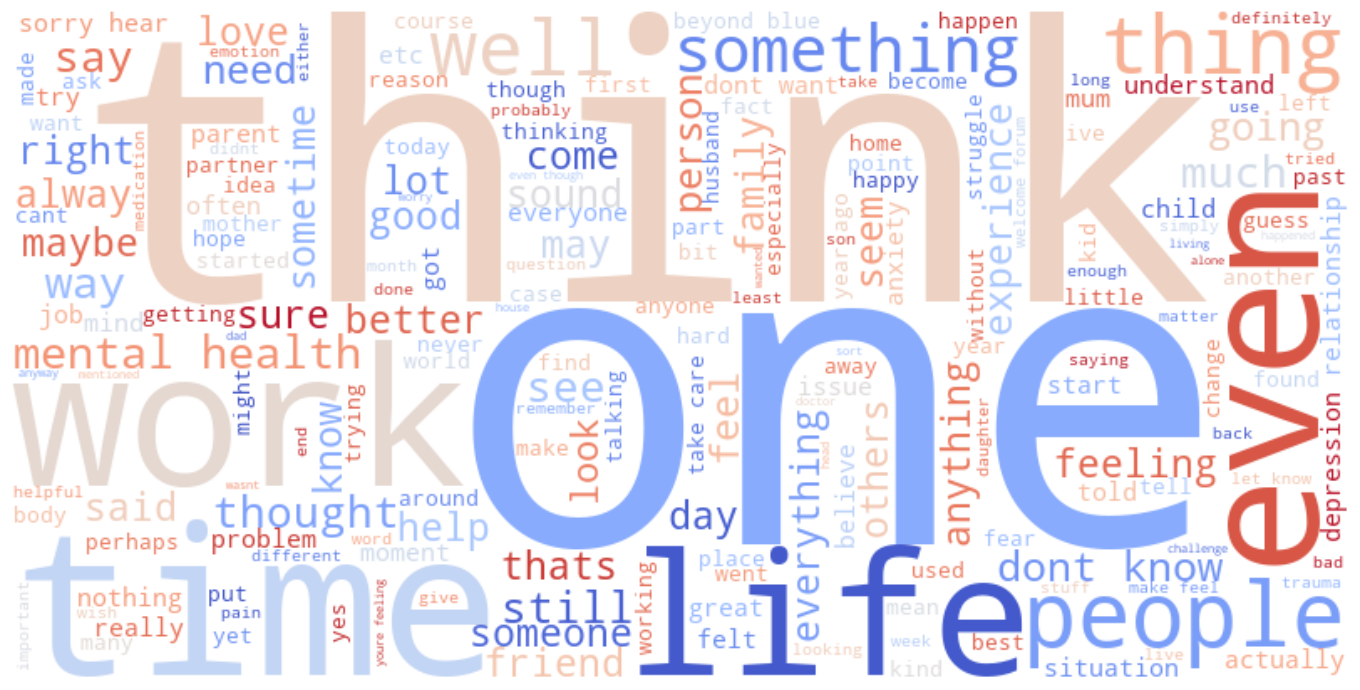

In [30]:
from wordcloud import WordCloud

# Combine all clean_text from df into a single string
all_text = " ".join(df['clean_text'].dropna())

# Generate the word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white', max_words=200, colormap='coolwarm').generate(all_text)

# Plot the word cloud
plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.tight_layout()
plt.show()

We can see that there are most common words show in the text, those words are neutural words. We will let feature extraction tools and LLM remove those words by themself.

/var/folders/0l/qgn1vqn15c3gw9rx0_bhcwq40000gn/T/ipykernel_85674/1077724871.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


(array([17532., 17897., 18262., 18628., 18993., 19358., 19723., 20089.]),
 [Text(17532.0, 0, '2018'),
  Text(17897.0, 0, '2019'),
  Text(18262.0, 0, '2020'),
  Text(18628.0, 0, '2021'),
  Text(18993.0, 0, '2022'),
  Text(19358.0, 0, '2023'),
  Text(19723.0, 0, '2024'),
  Text(20089.0, 0, '2025')])

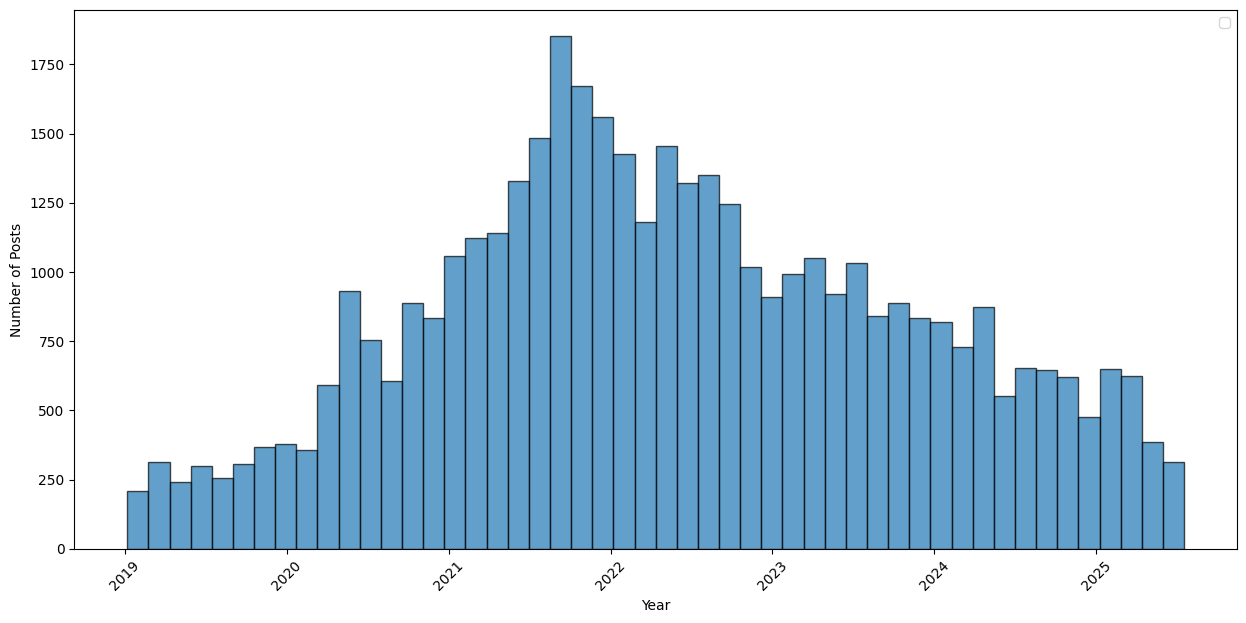

In [31]:
plt.figure(figsize=(15, 7))
plt.hist([df['timestamp']], 
                bins=50, alpha=0.7, edgecolor='black')
plt.xlabel('Year')
plt.ylabel('Number of Posts')
plt.legend()
plt.xticks(rotation=45)

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47,
  48,
  49,
  50,
  51,
  52,
  53,
  54,
  55,
  56,
  57,
  58,
  59,
  60,
  61,
  62,
  63,
  64,
  65,
  66,
  67,
  68,
  69,
  70,
  71,
  72,
  73,
  74,
  75,
  76,
  77,
  78],
 [Text(0, 0, '2019-01'),
  Text(1, 0, '2019-02'),
  Text(2, 0, '2019-03'),
  Text(3, 0, '2019-04'),
  Text(4, 0, '2019-05'),
  Text(5, 0, '2019-06'),
  Text(6, 0, '2019-07'),
  Text(7, 0, '2019-08'),
  Text(8, 0, '2019-09'),
  Text(9, 0, '2019-10'),
  Text(10, 0, '2019-11'),
  Text(11, 0, '2019-12'),
  Text(12, 0, '2020-01'),
  Text(13, 0, '2020-02'),
  Text(14, 0, '2020-03'),
  Text(15, 0, '2020-04'),
  Text(16, 0, '2020-05'),
  Text(17, 0, '2020-06'),
  Text(18, 0, '2020-07'),
  Text(19, 0, '2020-08'),
  Text(20, 0, '2020-09'),

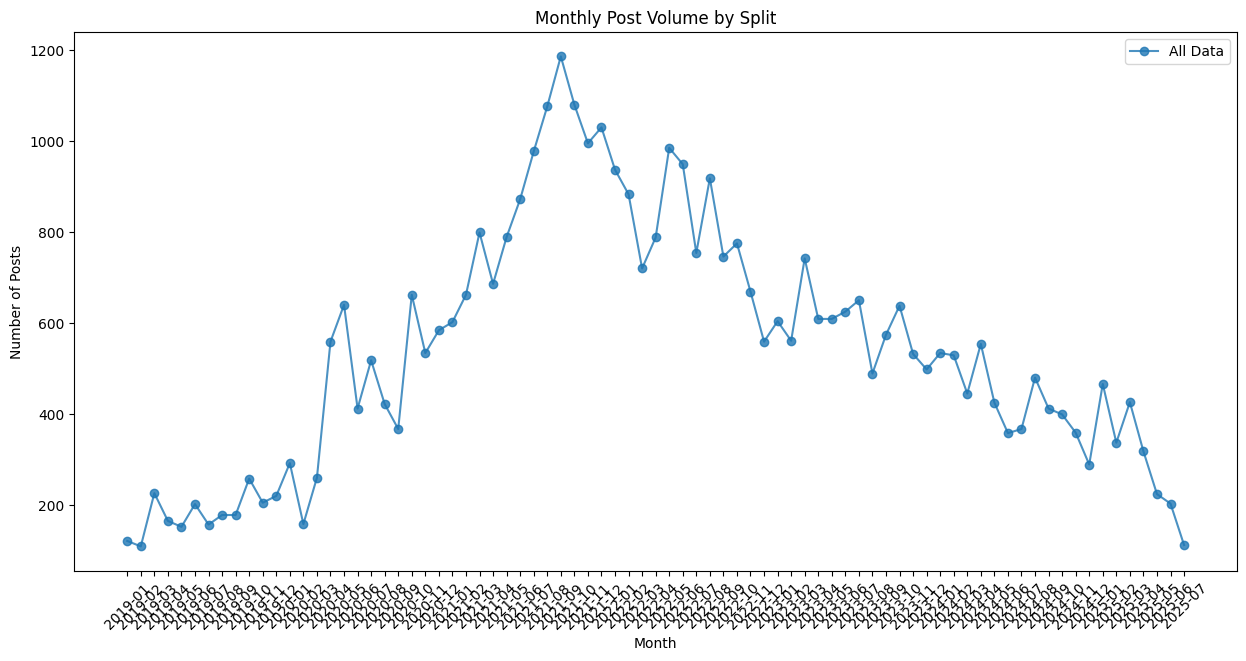

In [32]:
plt.figure(figsize=(15, 7))
df['month'] = df['timestamp'].dt.to_period('M')

monthly_df = df.groupby('month').size()

plt.plot(monthly_df.index.astype(str), monthly_df.values, 'o-', label='All Data', alpha=0.8)
plt.title('Monthly Post Volume by Split')
plt.xlabel('Month')
plt.ylabel('Number of Posts')
plt.legend()
plt.xticks(rotation=45)

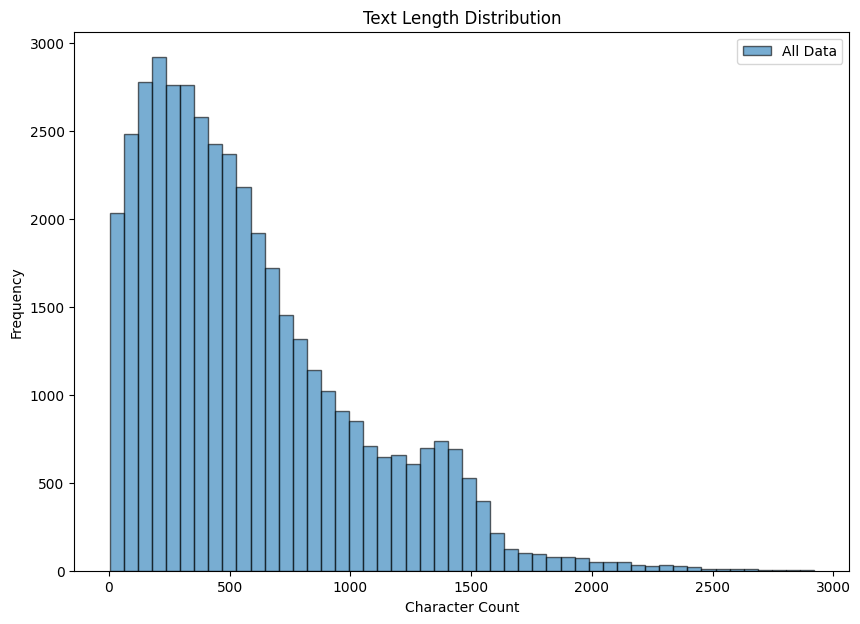

In [33]:
df['text_length'] = df['clean_text'].str.len()

plt.figure(figsize=(10, 7))
plt.hist([df['text_length']], 
         bins=50, alpha=0.6, label=['All Data'], edgecolor='black')
plt.title('Text Length Distribution')
plt.xlabel('Character Count')
plt.ylabel('Frequency')
plt.legend()
plt.show()

/var/folders/0l/qgn1vqn15c3gw9rx0_bhcwq40000gn/T/ipykernel_85674/309633633.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(text_data, labels=['All Data'])


Text(0, 0.5, 'Character Count')

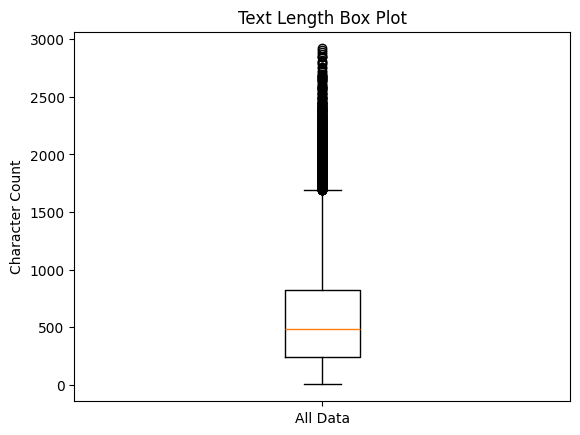

In [34]:
text_data = [df['text_length']]
plt.boxplot(text_data, labels=['All Data'])
plt.title('Text Length Box Plot')
plt.ylabel('Character Count')

### Summary of the Dataset

In [35]:
summary_stats = []
for split_name, split_df in [( "All Data", df)]:
    stats = {
        'Split': split_name,
        'Total Posts': len(split_df),
        'Unique Users': split_df['user_id'].nunique(),
        'Date Range (Days)': (split_df['timestamp'].max() - split_df['timestamp'].min()).days,
        'Avg Posts/User': round(len(split_df) / split_df['user_id'].nunique(), 2),
        'Avg Text Length': round(split_df['text_length'].mean(), 1),
        'Posts (%)': round(split_df['is_post'].sum() / len(split_df) * 100, 1),
        'Comments (%)': round((~split_df['is_post']).sum() / len(split_df) * 100, 1)
    }
    summary_stats.append(stats)

summary_df = pd.DataFrame(summary_stats)
print(summary_df.to_string(index=False))

print(f"\nOverall Dataset Distribution:")
overall_counts = df['category'].value_counts()
total_posts = len(df)
for category, count in overall_counts.items():
    percentage = count / total_posts * 100
    print(f"  {category:<30}: {count:>6} threads ({percentage:>5.1f}%)")

print("\nPercentage of posts/comments per category:")
for cat in post_comment_dist.index:
    true_pct = post_comment_dist.loc[cat, True]
    false_pct = post_comment_dist.loc[cat, False]
    print(f"  {cat:<30}: {true_pct:5.1f}% posts, {false_pct:5.1f}% comments")


   Split  Total Posts  Unique Users  Date Range (Days)  Avg Posts/User  Avg Text Length  Posts (%)  Comments (%)
All Data        42384          6318               2385            6.71            588.6       15.6          84.4

Overall Dataset Distribution:
  Depression                    :  11839 threads ( 27.9%)
  Anxiety                       :  11606 threads ( 27.4%)
  Suicidal thoughts and self-harm:   9741 threads ( 23.0%)
  PTSD and trauma               :   9198 threads ( 21.7%)

Percentage of posts/comments per category:
  Anxiety                       :  16.8% posts,  83.2% comments
  Depression                    :  16.6% posts,  83.4% comments
  PTSD and trauma               :  15.1% posts,  84.9% comments
  Suicidal thoughts and self-harm:  13.4% posts,  86.6% comments


### 2.2 Extract LIWC-style features (via Empath)
Interpretable, lexicon-based emotional dimensions. We will apply to the training dataset to compare which feature extraction has the higher impact. Due to the limitation of Empath, we will add custom categories to Empath.

In [36]:
from empath_analysis_pipeline import extract_empath_features, save_empath_features,load_empath_features, analyze_empath_results

empath_out, empath_weekly = extract_empath_features(
    df,
    text_column='clean_text',
    user_id_column='user_id',
    category_column='category',
    optimize_features=True
)

Initializing Empath lexicon...
Applying Empath analysis to text...
Empath analysis complete. Sample result: {'help': 0.04838709677419355, 'office': 0.016129032258064516, 'dance': 0.0, 'money': 0.0, 'wedding': 0.0, 'domestic_work': 0.024193548387096774, 'sleep': 0.0, 'medical_emergency': 0.0, 'cold': 0.016129032258064516, 'hate': 0.016129032258064516, 'cheerfulness': 0.008064516129032258, 'aggression': 0.0, 'occupation': 0.024193548387096774, 'envy': 0.0, 'anticipation': 0.0, 'family': 0.04032258064516129, 'vacation': 0.0, 'crime': 0.0, 'attractive': 0.016129032258064516, 'masculine': 0.0, 'prison': 0.0, 'health': 0.04838709677419355, 'pride': 0.0, 'dispute': 0.008064516129032258, 'nervousness': 0.04032258064516129, 'government': 0.0, 'weakness': 0.0, 'horror': 0.024193548387096774, 'swearing_terms': 0.0, 'leisure': 0.0, 'suffering': 0.056451612903225805, 'royalty': 0.0, 'wealthy': 0.0, 'tourism': 0.0, 'furniture': 0.0, 'school': 0.024193548387096774, 'magic': 0.008064516129032258, 'bea

In [37]:
save_empath_features(empath_out, empath_weekly, 
                     output_path="./data/empath_data.csv", 
                     weekly_path="./data/empath_weekly.csv")

Saved empath features to ./data/empath_data.csv
Saved weekly features to ./data/empath_weekly.csv


In [38]:
empath_df, empath_weekly = load_empath_features(
    data_path="./data/empath_data.csv", 
    weekly_path="./data/empath_weekly.csv"
)

Loaded empath features: (42384, 40)
Loaded weekly features: (16467, 32)


In [39]:
empath_weekly.head()

,user_id,week,empath_anger,empath_anxiety,empath_body,empath_business,empath_children,empath_communication,empath_contentment,empath_depression,...,empath_positive_emotion,empath_sadness,empath_shame,empath_sleep,empath_speaking,empath_suffering,empath_therapy,empath_trust,empath_violence,empath_work
0,1001,2025-07-14,0.000000,0.127011,0.032245,0.000000,0.009471,0.024999,0.035869,0.028413,...,0.034470,0.071374,0.039492,0.007246,0.030847,0.049998,0.039129,0.000000,0.026189,0.000000
1,1002,2025-07-07,0.000000,0.000000,0.000000,0.000000,0.071429,0.071429,0.000000,0.000000,...,0.071429,0.000000,0.000000,0.000000,0.071429,0.000000,0.000000,0.071429,0.000000,0.071429
2,1002,2025-07-14,0.000000,0.033660,0.027778,0.000000,0.023529,0.005882,0.027778,0.033660,...,0.005882,0.000000,0.027778,0.000000,0.005882,0.005882,0.017647,0.017647,0.033660,0.017647
3,1003,2025-07-14,0.000000,0.125000,0.020833,0.000000,0.000000,0.000000,0.041667,0.062500,...,0.020833,0.083333,0.104167,0.000000,0.020833,0.020833,0.000000,0.000000,0.020833,0.020833
4,1004,2023-10-16,0.003968,0.083405,0.025541,0.024242,0.003968,0.068543,0.025541,0.003968,...,0.033694,0.011905,0.047114,0.000000,0.023665,0.007937,0.010029,0.011544,0.041053,0.018182


In [40]:
VAD_MAPPED = [
    "empath_anxiety","empath_pain","empath_violence","empath_sadness","empath_depression",
    "empath_help","empath_love","empath_suffering","empath_health","empath_contentment",
    "empath_fear","empath_trust","empath_hate","empath_therapy","empath_sleep",
    "empath_anger","empath_shame","empath_optimism"
]

CONTEXT_ONLY = [
    "empath_positive_emotion","empath_negative_emotion","empath_speaking","empath_communication",
    "empath_body","empath_children","empath_friends","empath_family","empath_work",
    "empath_business","empath_money","empath_giving"
]

In [41]:
def select_for_vad(empath_out, min_prev=0.05):
    avail = [c for c in VAD_MAPPED if c in empath_out.columns]
    prev = (empath_out[avail] > 0).mean()
    keep = prev[prev >= min_prev].index.tolist()
    return keep

vad_cols = select_for_vad(empath_out, min_prev=0.05)
context_cols = [c for c in CONTEXT_ONLY if c in empath_out.columns]
print("VAD for NRC:", vad_cols)
print("Context (not in VAD):", context_cols)

# Save for reproducibility
with open("vad_cols.txt","w") as f:
    for c in vad_cols: f.write(c+"\n")

with open("context_cols.txt","w") as f:
    for c in context_cols: f.write(c+"\n")

VAD for NRC: ['empath_anxiety', 'empath_pain', 'empath_violence', 'empath_sadness', 'empath_depression', 'empath_help', 'empath_love', 'empath_suffering', 'empath_health', 'empath_contentment', 'empath_fear', 'empath_trust', 'empath_hate', 'empath_therapy', 'empath_sleep', 'empath_anger', 'empath_shame', 'empath_optimism']
Context (not in VAD): ['empath_positive_emotion', 'empath_negative_emotion', 'empath_speaking', 'empath_communication', 'empath_body', 'empath_children', 'empath_friends', 'empath_family', 'empath_work', 'empath_business', 'empath_money', 'empath_giving']


In [42]:
all_empath = [c for c in empath_out.columns if c.startswith("empath_")]
context_cols = [c for c in all_empath if c not in vad_cols]

df_vad      = empath_out[['user_id', 'post_id', 'comment_id', 'timestamp', 'date', 'week', 'is_post', 'category', 'thread_owner_id'] + vad_cols]
df_context  = empath_out[['user_id', 'post_id', 'comment_id', 'timestamp', 'date', 'week', 'is_post', 'category', 'thread_owner_id'] + context_cols]

In [43]:
print("All empath features:", len(all_empath))
print("VAD mapped features:", len(vad_cols))
print("Context only features:", len(context_cols))

print(empath_df.shape)
print(df_vad.shape)
print(df_context.shape)


All empath features: 30
VAD mapped features: 18
Context only features: 12
(42384, 40)
(42384, 27)
(42384, 21)


In [44]:
top_all = analyze_empath_results(empath_df)
print(top_all)

top_vad = analyze_empath_results(df_vad)
print(top_vad)

top_context = analyze_empath_results(df_context)
print(top_context)

Top 10 Empath Categories:
  anxiety             : 0.0448
  positive_emotion    : 0.0396
  negative_emotion    : 0.0325
  speaking            : 0.0307
  health              : 0.0295
  pain                : 0.0290
  communication       : 0.0290
  shame               : 0.0271
  sadness             : 0.0270
  optimism            : 0.0264
empath_anxiety             0.044823
empath_positive_emotion    0.039583
empath_negative_emotion    0.032519
empath_speaking            0.030722
empath_health              0.029511
empath_pain                0.029039
empath_communication       0.029029
empath_shame               0.027118
empath_sadness             0.027027
empath_optimism            0.026412
dtype: float64
Top 10 Empath Categories:
  anxiety             : 0.0448
  health              : 0.0295
  pain                : 0.0290
  shame               : 0.0271
  sadness             : 0.0270
  optimism            : 0.0264
  depression          : 0.0247
  violence            : 0.0234
  help         

In [45]:
with open("empath_selected_columns.txt") as f:
    print("Selected Empath cols:", [l.strip() for l in f])
    
with open("vad_cols.txt") as f:
    print("VAD cols:", [l.strip() for l in f])
    
with open("context_cols.txt") as f:
    print("Context cols:", [l.strip() for l in f])

Selected Empath cols: ['empath_anger', 'empath_anxiety', 'empath_body', 'empath_business', 'empath_children', 'empath_communication', 'empath_contentment', 'empath_depression', 'empath_family', 'empath_fear', 'empath_friends', 'empath_giving', 'empath_hate', 'empath_health', 'empath_help', 'empath_love', 'empath_money', 'empath_negative_emotion', 'empath_optimism', 'empath_pain', 'empath_positive_emotion', 'empath_sadness', 'empath_shame', 'empath_sleep', 'empath_speaking', 'empath_suffering', 'empath_therapy', 'empath_trust', 'empath_violence', 'empath_work']
VAD cols: ['empath_anxiety', 'empath_pain', 'empath_violence', 'empath_sadness', 'empath_depression', 'empath_help', 'empath_love', 'empath_suffering', 'empath_health', 'empath_contentment', 'empath_fear', 'empath_trust', 'empath_hate', 'empath_therapy', 'empath_sleep', 'empath_anger', 'empath_shame', 'empath_optimism']
Context cols: ['empath_positive_emotion', 'empath_negative_emotion', 'empath_speaking', 'empath_communication',

In [46]:
top_emotions = analyze_empath_results(empath_df)

top_vad = analyze_empath_results(df_vad)

top_context = analyze_empath_results(df_context)

Top 10 Empath Categories:
  anxiety             : 0.0448
  positive_emotion    : 0.0396
  negative_emotion    : 0.0325
  speaking            : 0.0307
  health              : 0.0295
  pain                : 0.0290
  communication       : 0.0290
  shame               : 0.0271
  sadness             : 0.0270
  optimism            : 0.0264
Top 10 Empath Categories:
  anxiety             : 0.0448
  health              : 0.0295
  pain                : 0.0290
  shame               : 0.0271
  sadness             : 0.0270
  optimism            : 0.0264
  depression          : 0.0247
  violence            : 0.0234
  help                : 0.0231
  suffering           : 0.0218
Top 10 Empath Categories:
  positive_emotion    : 0.0396
  negative_emotion    : 0.0325
  speaking            : 0.0307
  communication       : 0.0290
  giving              : 0.0211
  children            : 0.0187
  friends             : 0.0169
  body                : 0.0165
  family              : 0.0163
  business            :

<Axes: >

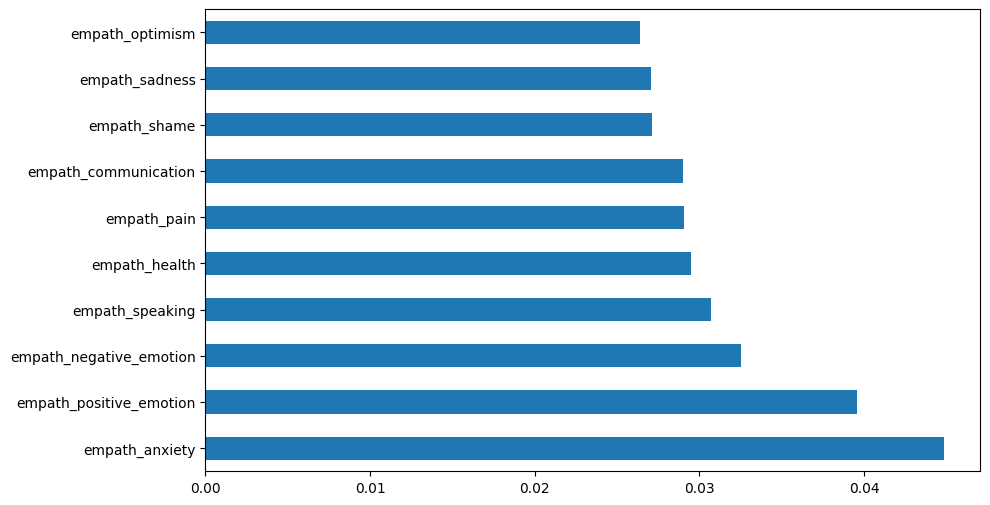

In [47]:
top_emotions.plot(kind='barh', figsize=(10, 6))

<Axes: >

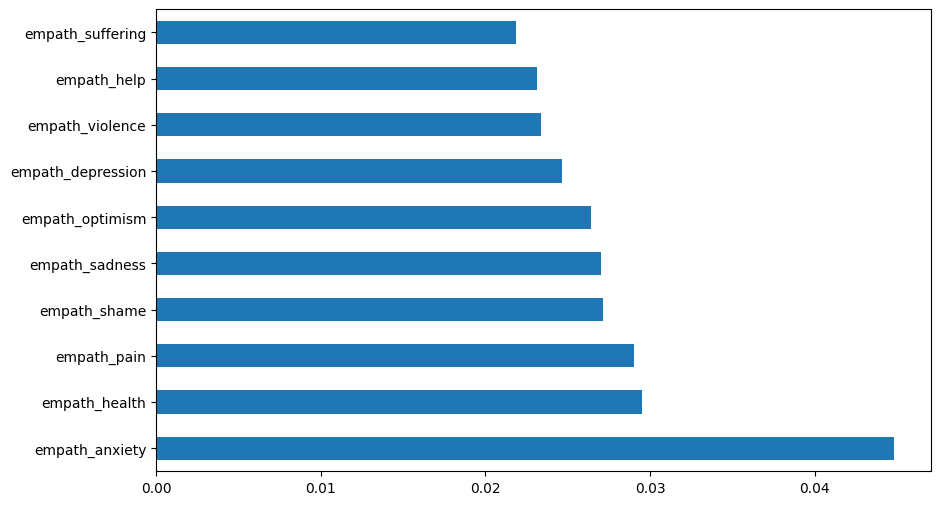

In [48]:
top_vad.plot(kind='barh', figsize=(10, 6))

<Axes: >

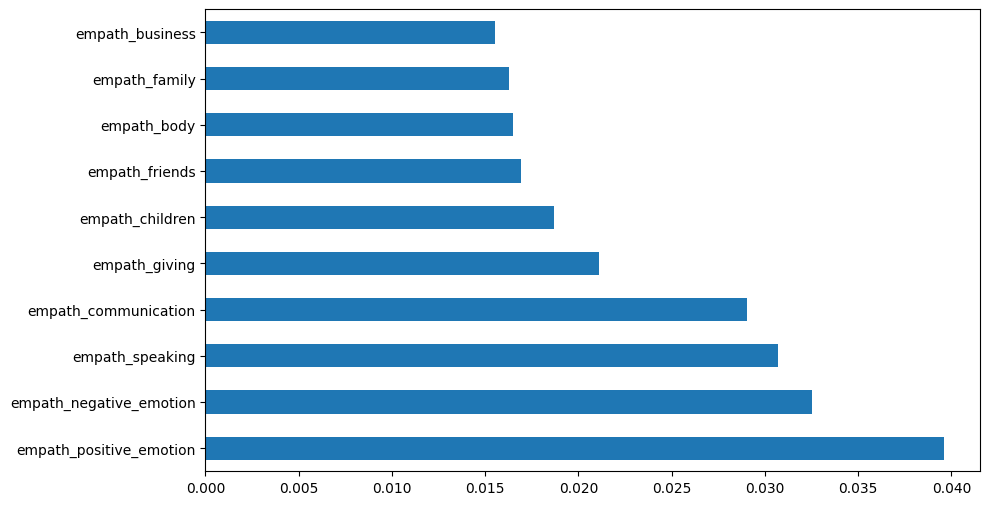

In [49]:
top_context.plot(kind='barh', figsize=(10, 6))

<Axes: title={'center': 'Top Empath Emotions Over Time'}, xlabel='date'>

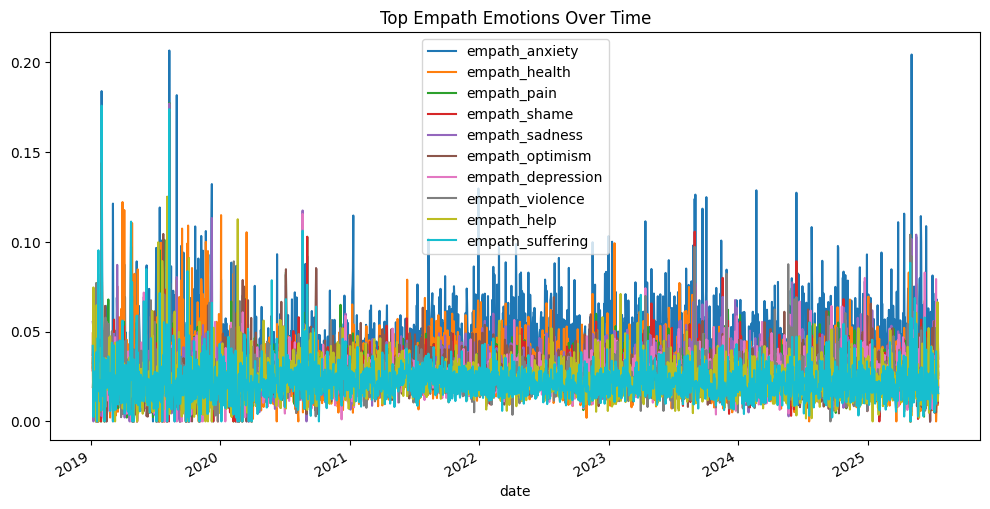

In [50]:
daily_emotions = df_vad.groupby('date')[top_vad.index].mean()

daily_emotions.plot(figsize=(12,6), title="Top Empath Emotions Over Time")

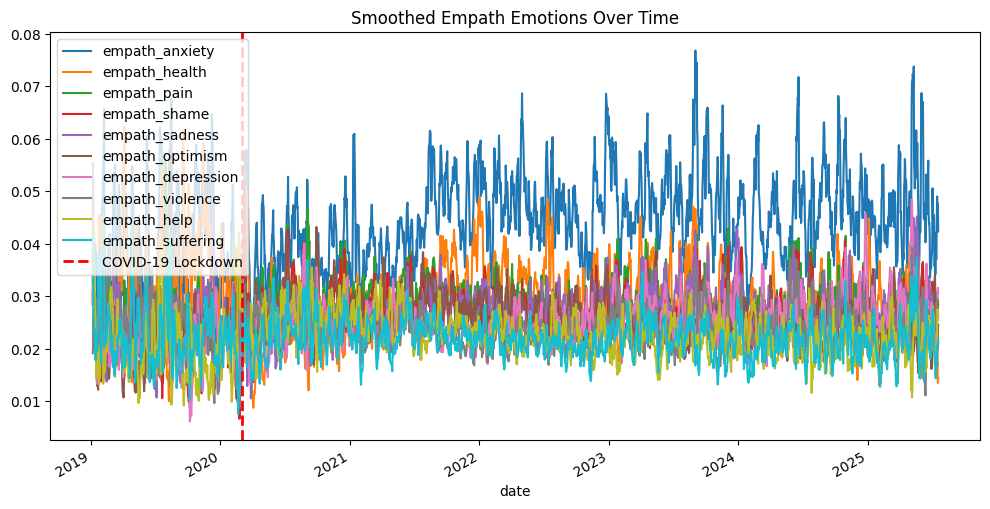

In [51]:
smoothed = daily_emotions.rolling(window=7, min_periods=1).mean()
smoothed.plot(figsize=(12,6), title="Smoothed Empath Emotions Over Time")

plt.axvline(pd.Timestamp('2020-03-01'), color='red', linestyle='--', linewidth=2, label='COVID-19 Lockdown')
plt.legend()

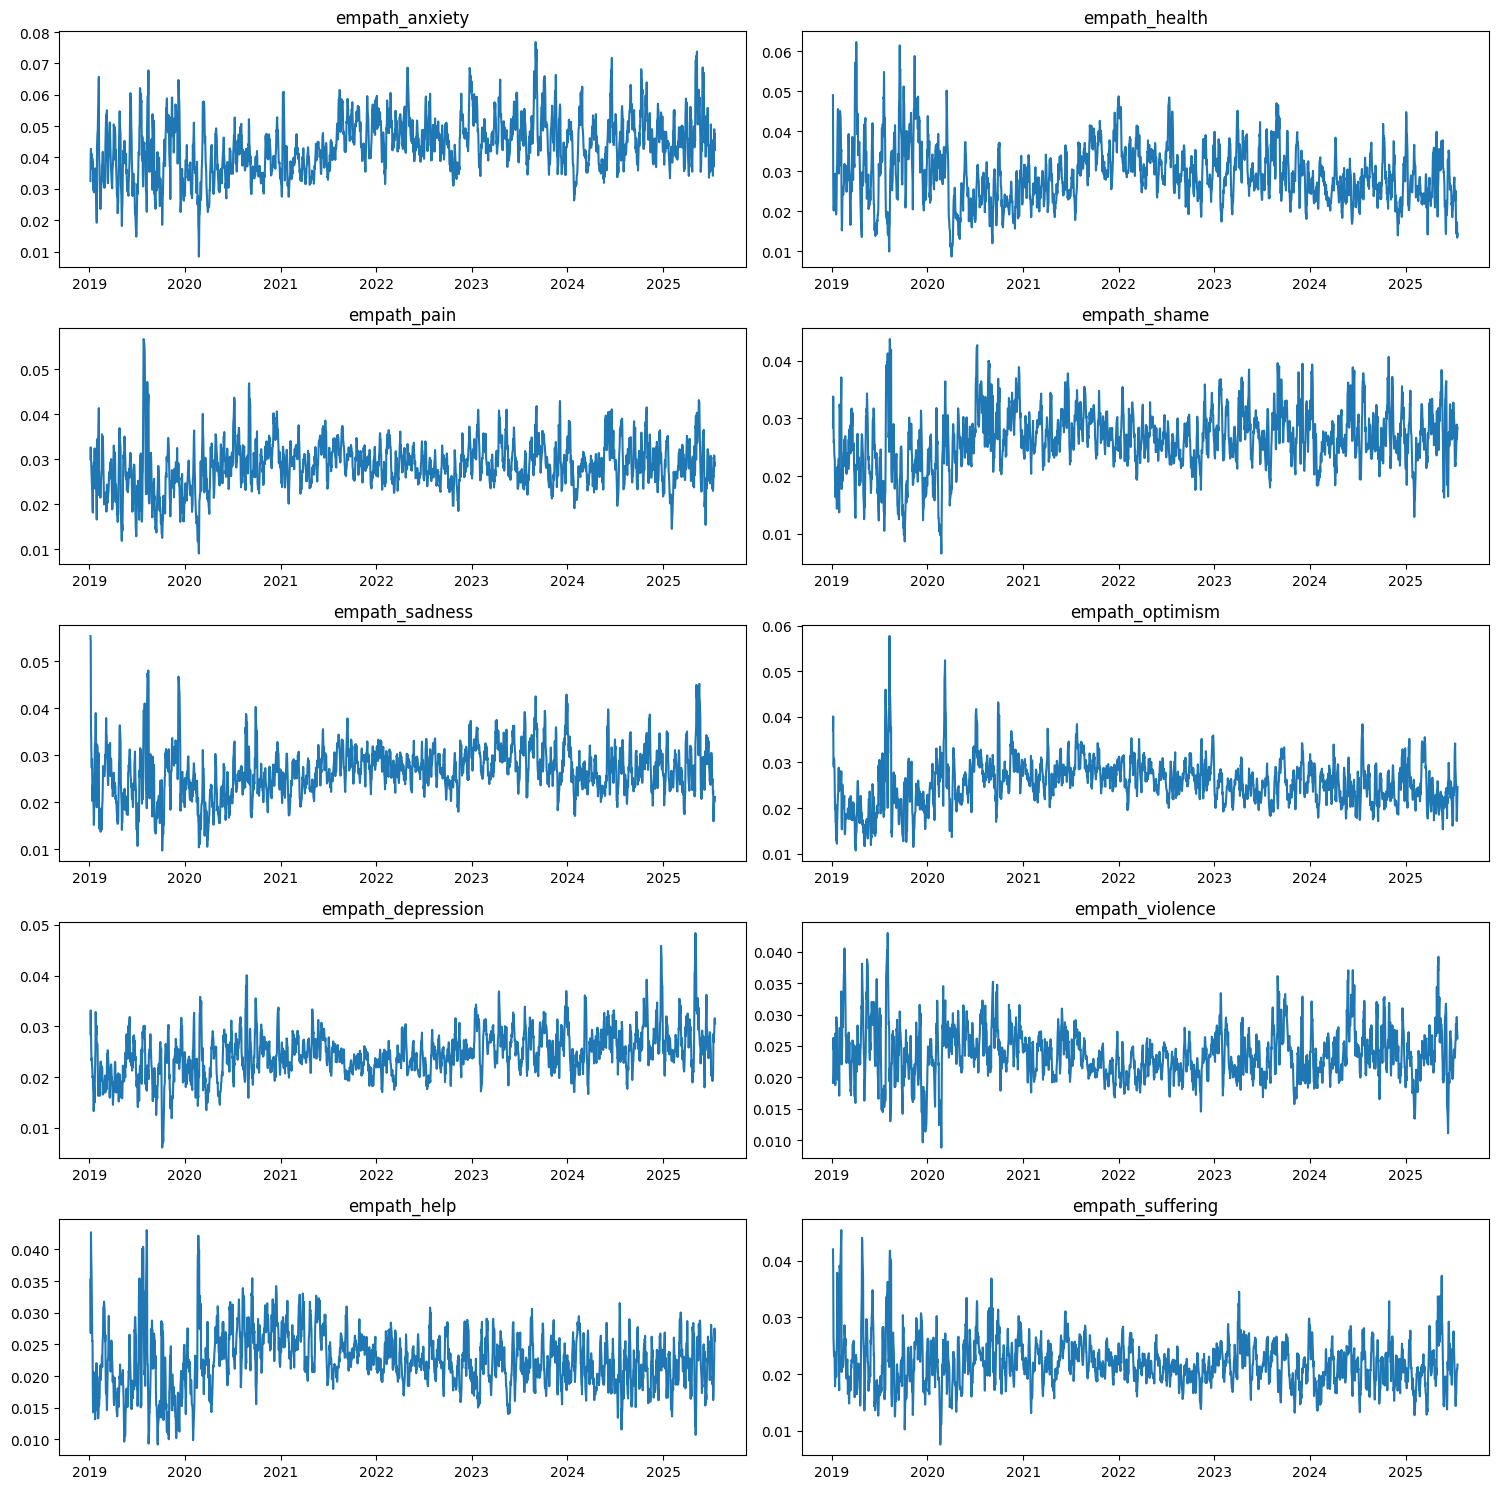

In [52]:
fig, axs = plt.subplots(5, 2, figsize=(15, 15))
axs = axs.flatten()

for i, col in enumerate(top_vad.index):
    axs[i].plot(smoothed[col])
    axs[i].set_title(col)

plt.tight_layout()

/var/folders/0l/qgn1vqn15c3gw9rx0_bhcwq40000gn/T/ipykernel_85674/1372045529.py:5: ClusterWarning: scipy.cluster: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z = sch.linkage(1 - C.abs(), method='average')


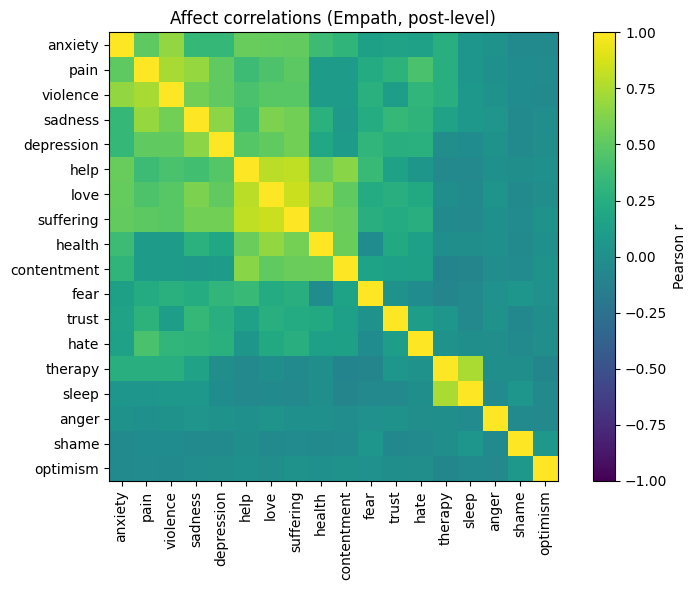

In [53]:
import scipy.cluster.hierarchy as sch
import numpy as np, pandas as pd
vc2 = [c for c in vad_cols if c in empath_df.columns]
C = empath_df[vc2].corr()
Z = sch.linkage(1 - C.abs(), method='average')
order = sch.leaves_list(Z)
C_sorted = C.iloc[order, order]

plt.figure(figsize=(8,6))
plt.imshow(C_sorted, vmin=-1, vmax=1)
plt.xticks(range(len(vc2)), [c.replace('empath_','') for c in vc2], rotation=90)
plt.yticks(range(len(vc2)), [c.replace('empath_','') for c in vc2])
plt.colorbar(label='Pearson r')
plt.title('Affect correlations (Empath, post-level)')
plt.tight_layout(); plt.show()

In [54]:
Z = empath_df[vc2].apply(lambda s: (s - s.mean())/(s.std(ddof=0)+1e-8))
empath_df['affect_intensity'] = np.sqrt((Z**2).sum(axis=1))
weekly_intensity = empath_df.groupby('week')['affect_intensity'].mean().reset_index()
weekly_intensity['roll8'] = weekly_intensity['affect_intensity'].rolling(8, min_periods=1).mean()

In [55]:
POS = [c for c in ['empath_love','empath_trust','empath_optimism','empath_contentment'] if c in empath_df.columns]
NEG = [c for c in ['empath_anxiety','empath_sadness','empath_shame','empath_anger','empath_fear',
                   'empath_pain','empath_suffering','empath_hate','empath_depression'] if c in empath_df.columns]
empath_df['pos_mean'] = empath_df[POS].mean(axis=1)
empath_df['neg_mean'] = empath_df[NEG].mean(axis=1)
bal = empath_df.groupby('week')[['pos_mean','neg_mean']].mean()
bal['pos_minus_neg'] = bal['pos_mean'] - bal['neg_mean']

In [56]:
op_means = empath_df.groupby('is_post')[vc2].mean().T.sort_values(by=True, ascending=False)

In [57]:
weeks_per = empath_weekly.groupby('user_id')['week'].nunique()

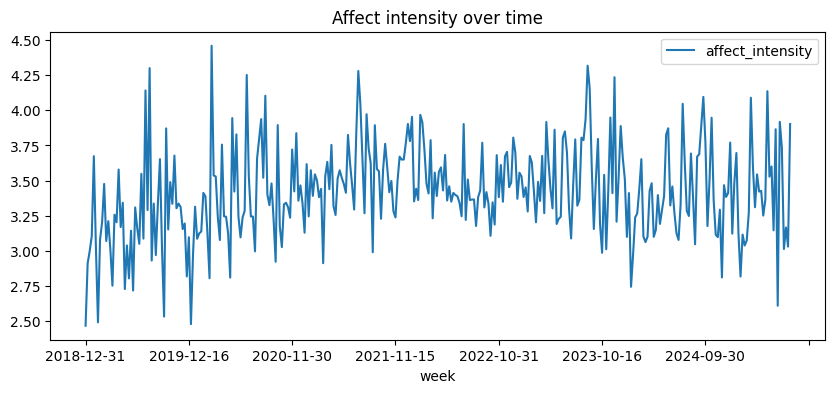

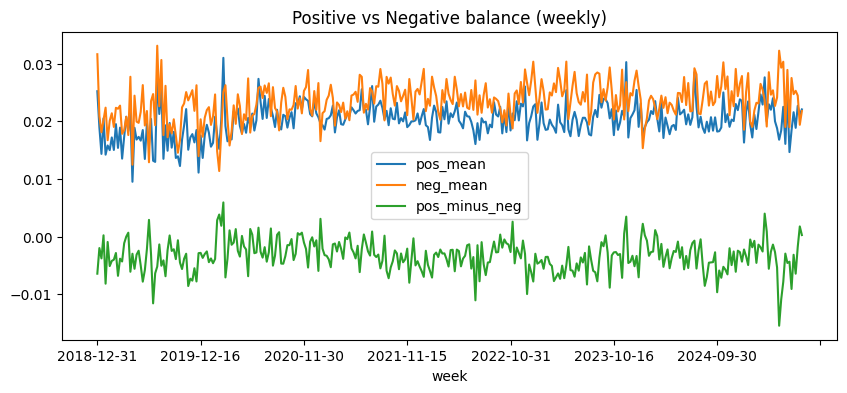

In [58]:
weekly_intensity.plot(x='week', y='affect_intensity', figsize=(10,4), title='Affect intensity over time');

bal[['pos_mean','neg_mean','pos_minus_neg']].plot(figsize=(10,4), title='Positive vs Negative balance (weekly)');

Text(0, 0.5, 'score')

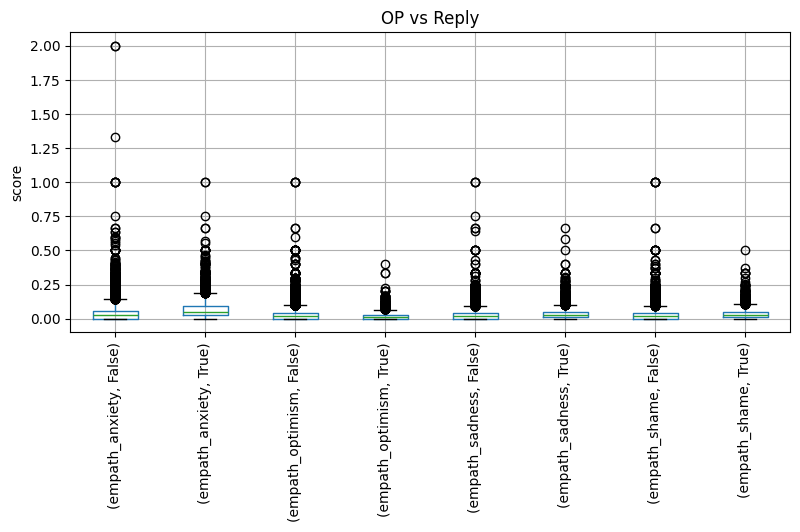

In [59]:
pick = ['empath_anxiety','empath_sadness','empath_shame','empath_optimism']
dfm = empath_df[['is_post']+pick].melt('is_post', var_name='feat', value_name='score')
ax = dfm.boxplot(by=['feat','is_post'], column='score', rot=90, figsize=(9,4))
plt.suptitle(''); plt.title('OP vs Reply'); plt.xlabel(''); plt.ylabel('score')

Text(0, 0.5, 'mean score')

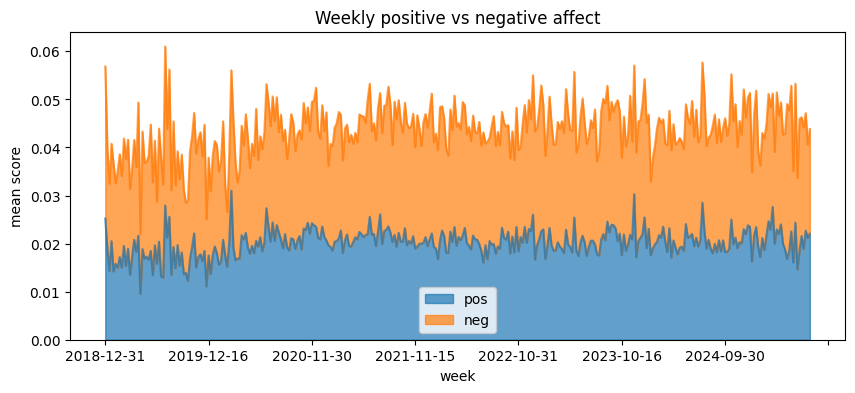

In [60]:
POS = [c for c in ['empath_love','empath_trust','empath_optimism','empath_contentment'] if c in empath_df.columns]
NEG = [c for c in ['empath_anxiety','empath_sadness','empath_shame','empath_anger','empath_fear','empath_pain','empath_suffering','empath_hate','empath_depression'] if c in empath_df.columns]
tmp = empath_df.assign(pos=empath_df[POS].mean(axis=1), neg=empath_df[NEG].mean(axis=1))
wk = tmp.groupby('week')[['pos','neg']].mean()
wk.plot.area(figsize=(10,4), alpha=.7, title='Weekly positive vs negative affect'); plt.ylabel('mean score')

Text(0.5, 0, 'fraction of posts')

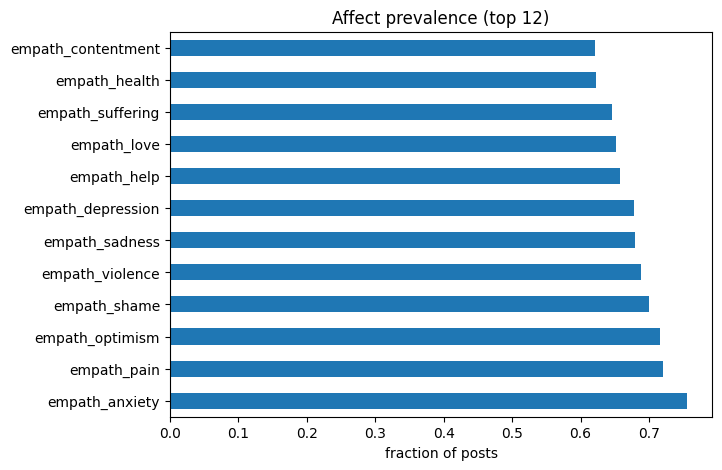

In [61]:
prev = (empath_df[vc2] > 0).mean().sort_values(ascending=False).head(12)
prev.plot(kind='barh', figsize=(7,5), title='Affect prevalence (top 12)'); plt.xlabel('fraction of posts')

#### 2.2.1 Weekly analysis for Empath

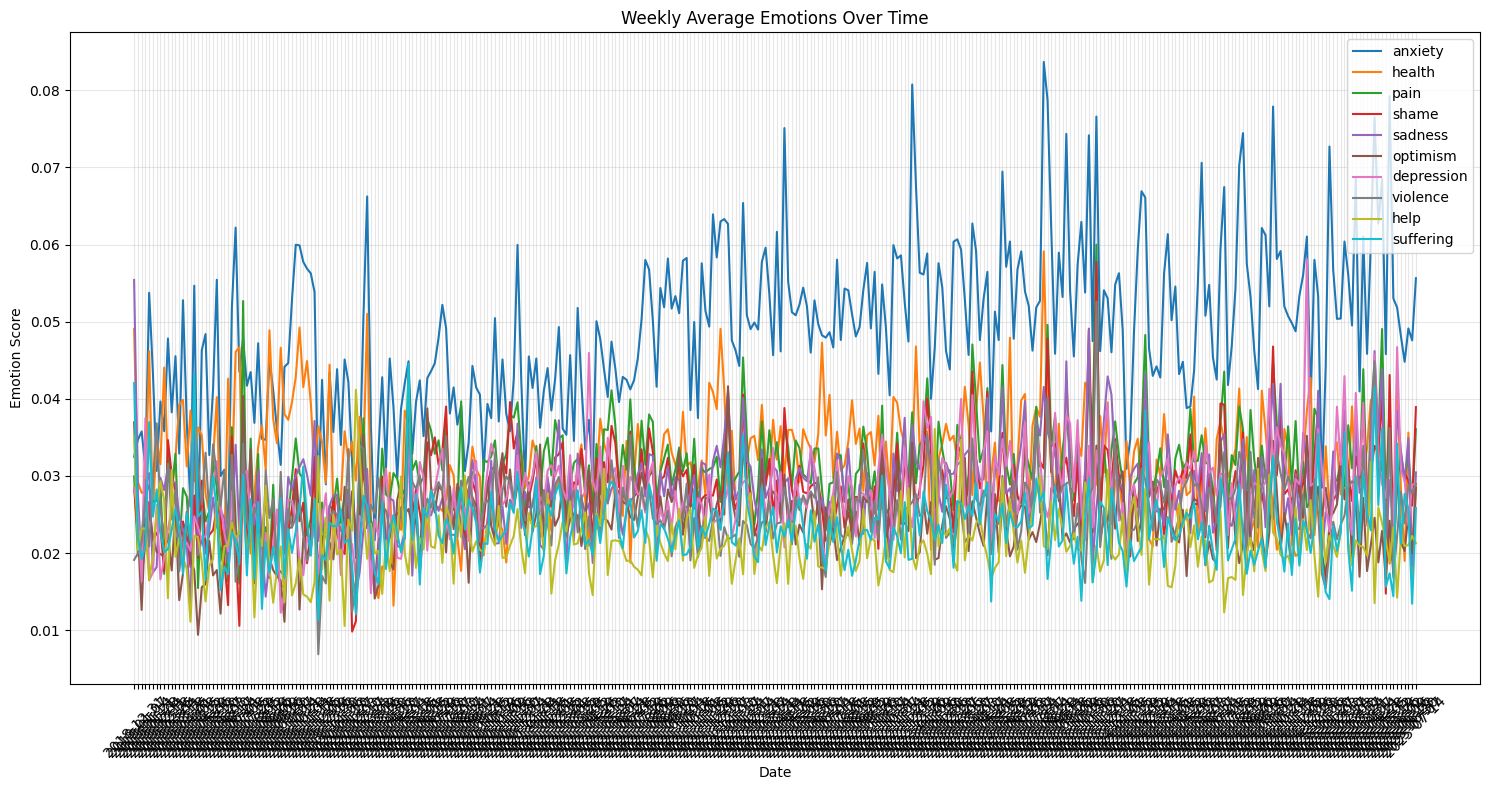

In [62]:
# Convert week to datetime for plotting
empath_weekly = empath_weekly[['user_id', 'week'] + vad_cols]
weekly_avg = empath_weekly.groupby('week')[top_vad.index].mean()

# Plot top emotions over time
plt.figure(figsize=(15, 8))
plt.plot(weekly_avg.index, weekly_avg.values)
plt.title('Weekly Average Emotions Over Time')
plt.xlabel('Date')
plt.ylabel('Emotion Score')
plt.legend([e.replace('empath_', '') for e in top_vad.index], loc='upper right', fontsize=10)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

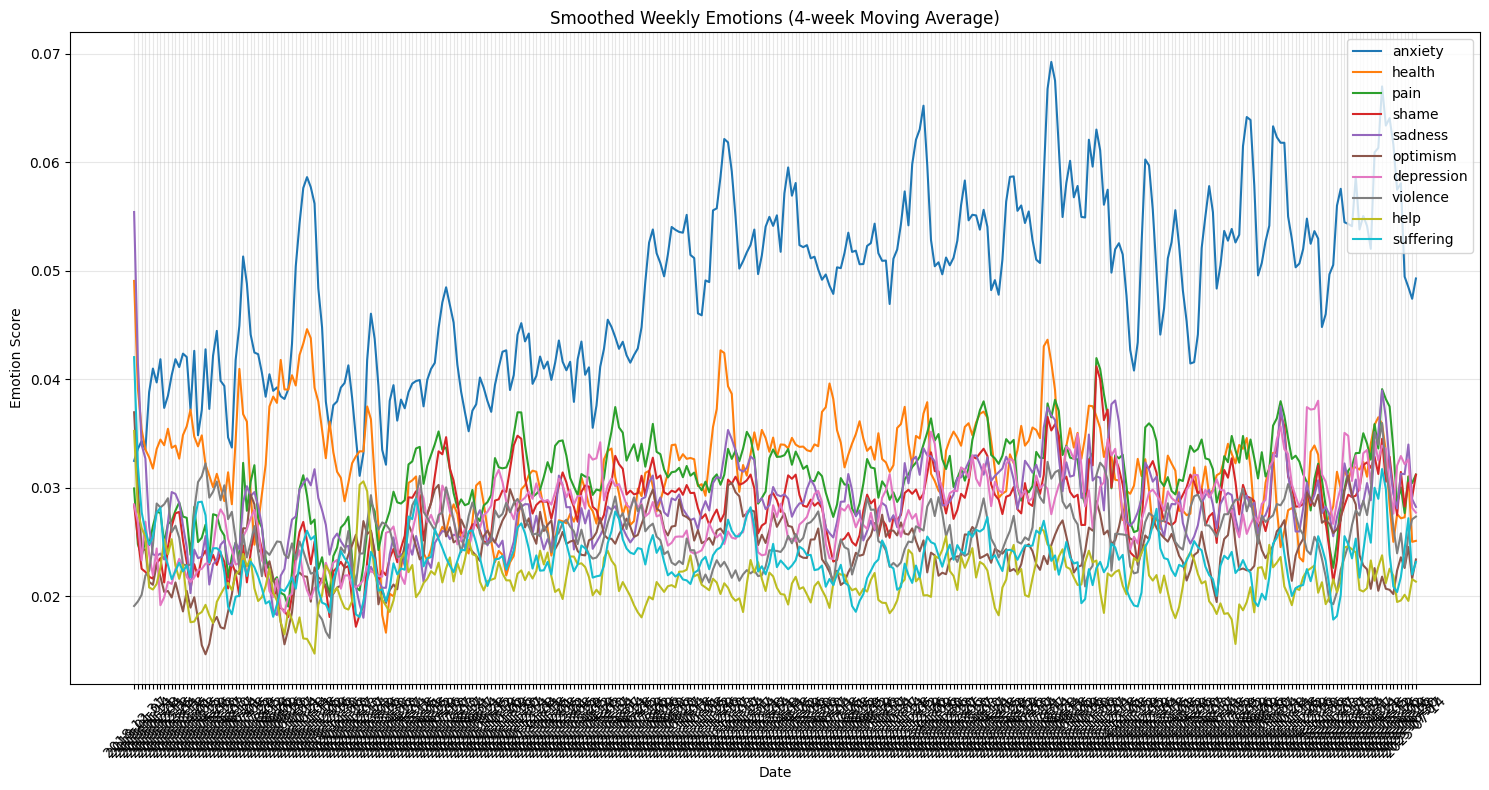

In [63]:
smoothed = weekly_avg.rolling(window=4, min_periods=1).mean()

plt.figure(figsize=(15, 8))
plt.plot(smoothed.index, smoothed.values)
plt.title('Smoothed Weekly Emotions (4-week Moving Average)')
plt.xlabel('Date')
plt.ylabel('Emotion Score')
plt.legend([e.replace('empath_', '') for e in top_vad.index], loc='upper right', fontsize=10)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

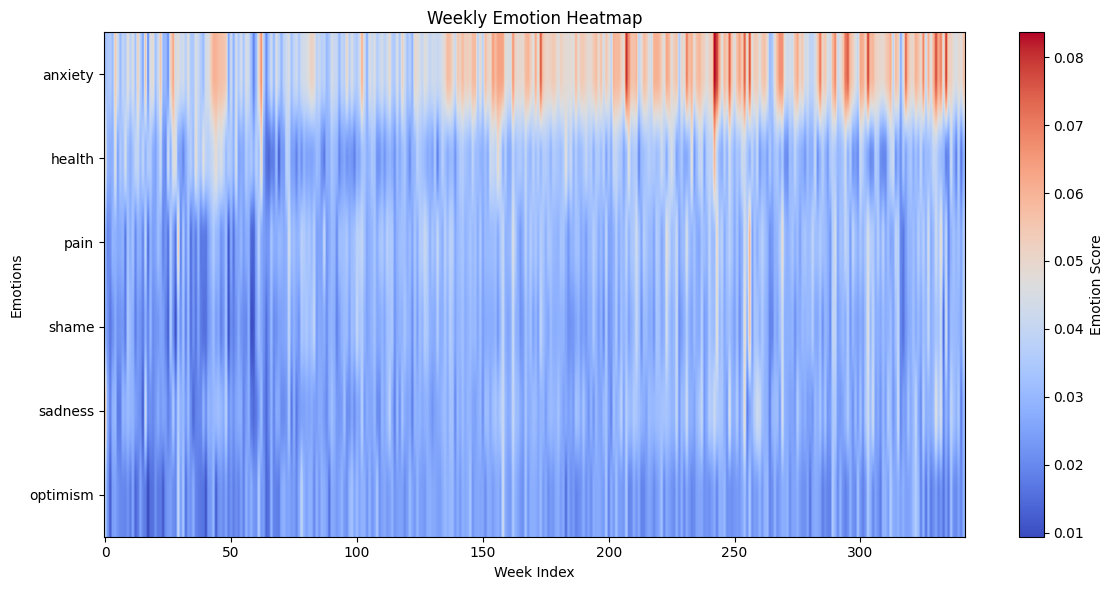

In [64]:
weekly_pivot = empath_weekly.groupby('week')[top_vad.index[:6]].mean()

plt.figure(figsize=(12, 6))
plt.imshow(weekly_pivot.T, cmap='coolwarm', aspect='auto')
plt.title('Weekly Emotion Heatmap')
plt.xlabel('Week Index')
plt.ylabel('Emotions')
plt.yticks(range(len(top_vad.index[:6])), [e.replace('empath_', '') for e in top_vad.index[:6]])
plt.colorbar(label='Emotion Score')
plt.tight_layout()
plt.show()

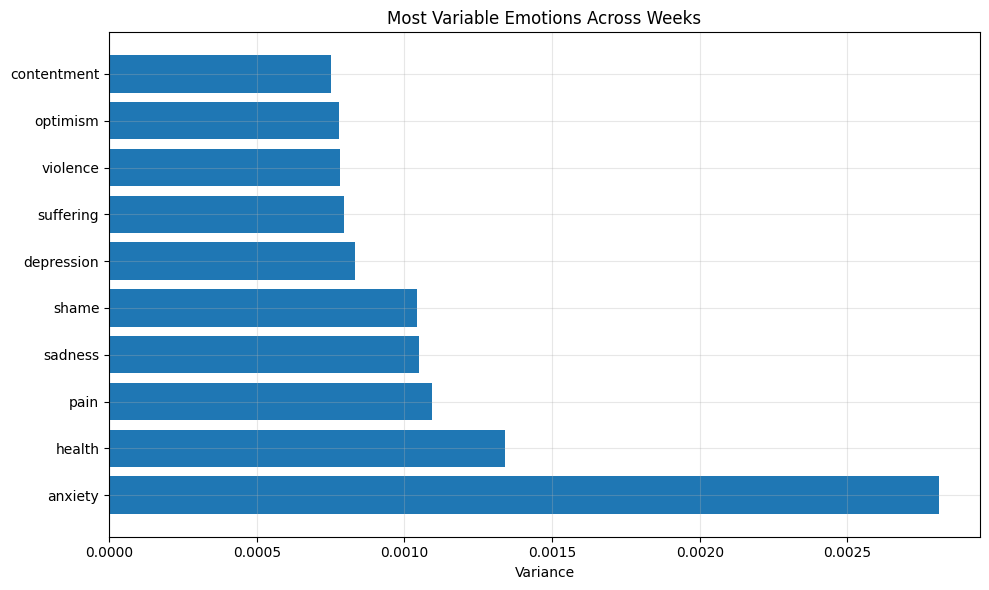

In [65]:
# Weekly emotion variance
emotion_variance = empath_weekly.groupby('week')[vad_cols].var().mean()
top_varying = emotion_variance.sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.barh(range(len(top_varying)), top_varying.values)
plt.yticks(range(len(top_varying)), [e.replace('empath_', '') for e in top_varying.index])
plt.title('Most Variable Emotions Across Weeks')
plt.xlabel('Variance')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

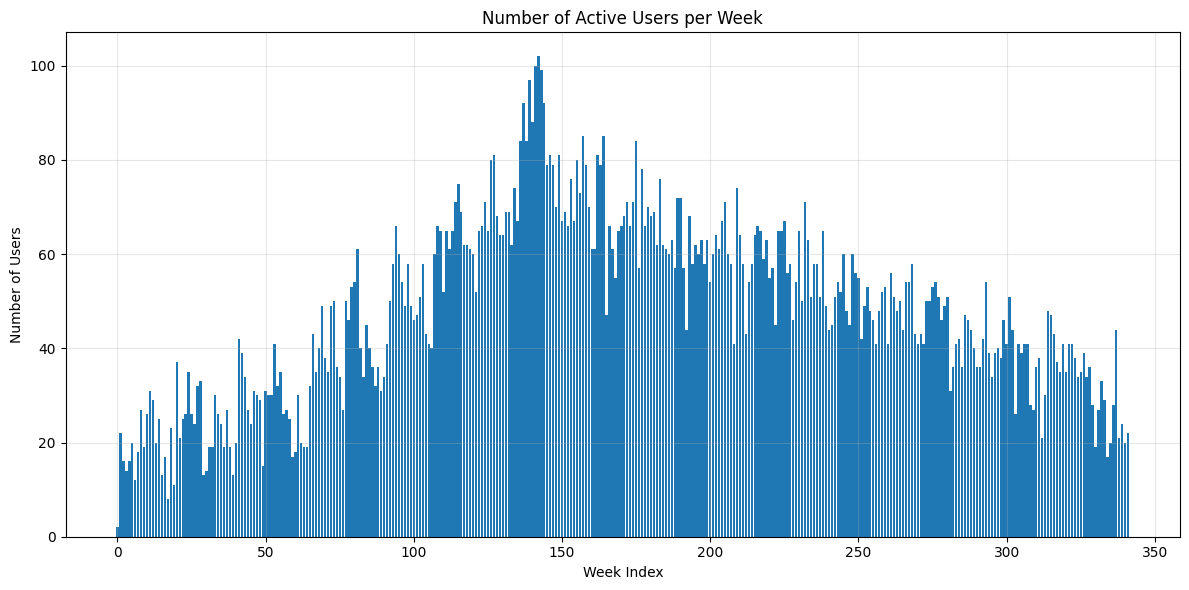

In [66]:
# User posting frequency by week
user_counts = empath_weekly.groupby('week')['user_id'].nunique()

plt.figure(figsize=(12, 6))
plt.bar(range(len(user_counts)), user_counts.values)
plt.title('Number of Active Users per Week')
plt.xlabel('Week Index')
plt.ylabel('Number of Users')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

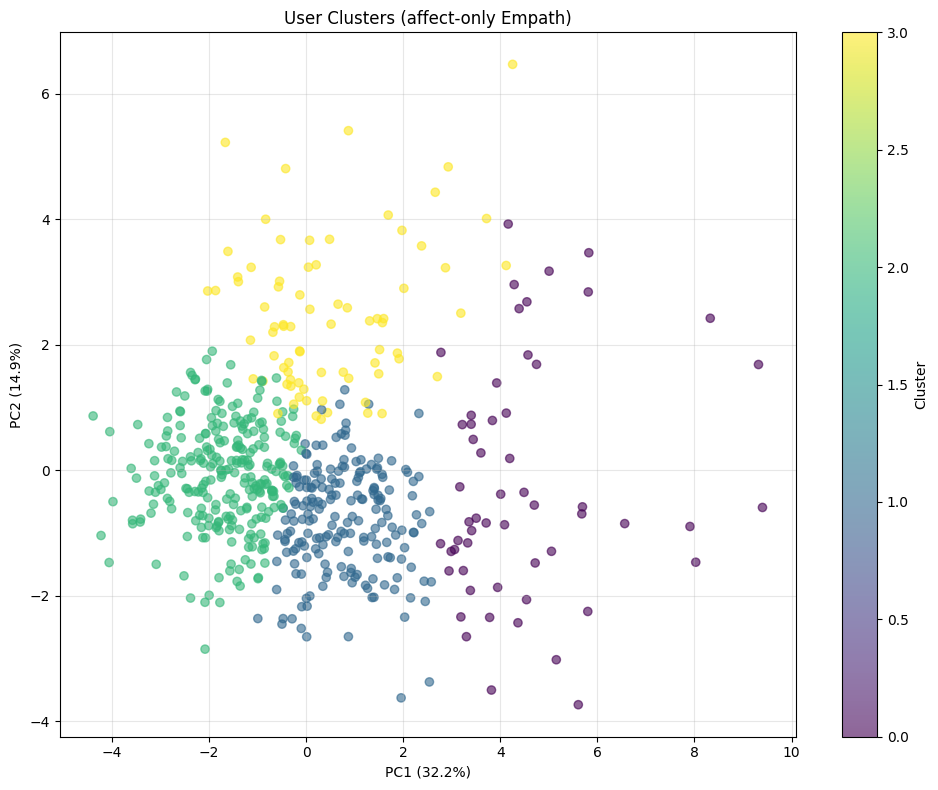

In [ ]:
weeks_per_user = empath_weekly.groupby('user_id')['week'].nunique()
keep_users = weeks_per_user[weeks_per_user >= 4].index
user_profiles = empath_weekly[empath_weekly.user_id.isin(keep_users)] \
                  .groupby('user_id')[vad_cols].mean()
                  
def winsorize_df(df, q=0.99):
    hi = df.quantile(q); lo = df.quantile(1-q)
    return df.clip(lower=lo, upper=hi, axis=1)
user_profiles_w = winsorize_df(user_profiles, q=0.99)



# scale + PCA + KMeans
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

X = RobustScaler().fit_transform(user_profiles_w)
pca = PCA(n_components=2, random_state=42)
Z = pca.fit_transform(X)
clusters = KMeans(n_clusters=4, random_state=42).fit_predict(X)

# plot
plt.figure(figsize=(10,8))
sc = plt.scatter(Z[:,0], Z[:,1], c=clusters, cmap='viridis', alpha=0.6)
plt.title('User Clusters (affect-only Empath)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.colorbar(sc, label='Cluster'); plt.grid(True, alpha=.3); plt.tight_layout(); plt.show()


Best k by silhouette: (2, 0.2450592669306411)


,empath_anxiety,empath_pain,empath_violence,empath_sadness,empath_depression,empath_help,empath_love,empath_suffering,empath_health,empath_contentment,empath_fear,empath_trust,empath_hate,empath_therapy,empath_sleep,empath_anger,empath_shame,empath_optimism
cluster,,,,,,,,,,,,,,,,,,
0,0.069644,0.047471,0.033407,0.040986,0.034289,0.018635,0.028470,0.033752,0.03544,0.031962,0.029713,0.013161,0.023375,0.015047,0.007774,0.009366,0.043381,0.031990
1,0.037165,0.022910,0.020726,0.021851,0.024143,0.019505,0.017091,0.017871,0.02966,0.014488,0.014162,0.013888,0.012788,0.014842,0.005745,0.005350,0.020847,0.023149


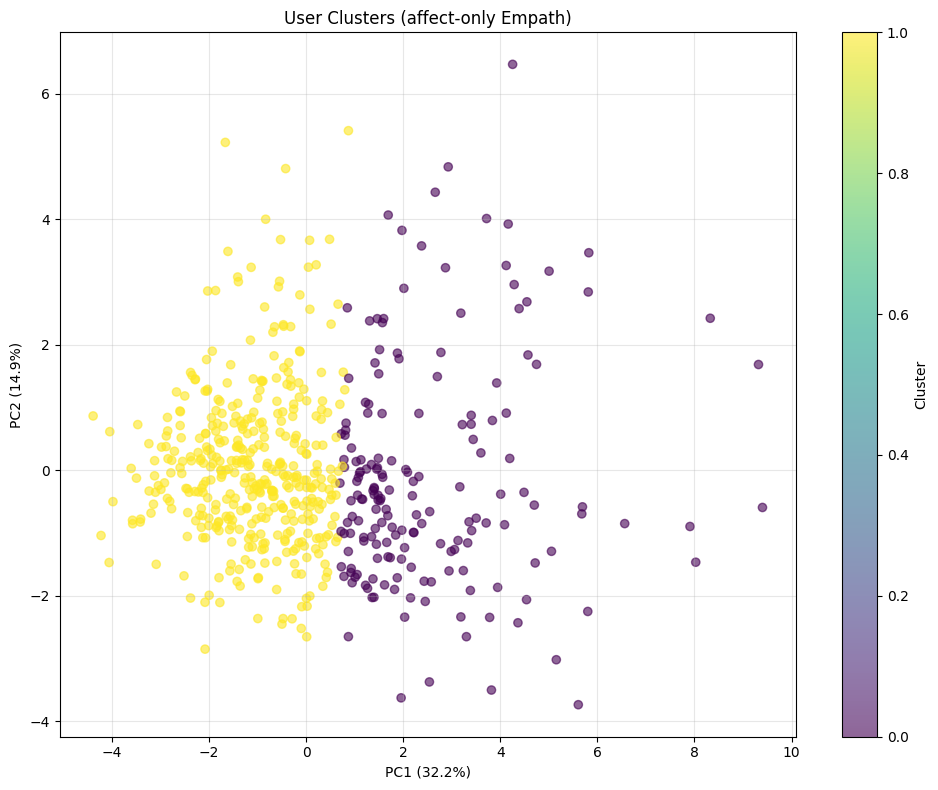

In [68]:
from sklearn.metrics import silhouette_score
X = RobustScaler().fit_transform(user_profiles_w)
best = max([(k, silhouette_score(X, KMeans(k, random_state=42).fit_predict(X)))
            for k in range(2,7)], key=lambda t:t[1])
print("Best k by silhouette:", best)
k = best[0]
clusters = KMeans(n_clusters=k, random_state=42).fit_predict(X)

centroids = pd.DataFrame(
    KMeans(n_clusters=k, random_state=42).fit(X).cluster_centers_,
    columns=[f"z_{c}" for c in user_profiles_w.columns]
)
group_means = user_profiles_w.assign(cluster=clusters).groupby('cluster')[vad_cols].mean()
display(group_means.sort_index())

# plot
plt.figure(figsize=(10,8))
sc = plt.scatter(Z[:,0], Z[:,1], c=clusters, cmap='viridis', alpha=0.6)
plt.title('User Clusters (affect-only Empath)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.colorbar(sc, label='Cluster'); plt.grid(True, alpha=.3); plt.tight_layout(); plt.show()

In [ ]:
def kmeans_silhouette(X, ks=(2,3,4,5,6)):
    out = []
    for k in ks:
        labels = KMeans(k, random_state=42).fit_predict(X)
        s = silhouette_score(X, labels)
        out.append((k, s))
    return out

print(kmeans_silhouette(X, ks=(2,3,4,5)))

pd.Series(clusters).value_counts().sort_index()

loadings = pd.Series(pca.components_[0], index=user_profiles_w.columns).sort_values(key=abs, ascending=False)
print("Top PC1 loadings:\n", loadings.head(8))
loadings2 = pd.Series(pca.components_[1], index=user_profiles_w.columns).sort_values(key=abs, ascending=False)
print("Top PC2 loadings:\n", loadings2.head(8))

group_means = user_profiles_w.assign(cluster=clusters)\
                             .groupby('cluster')[user_profiles_w.columns].mean()\
                             .sort_index()
display(group_means)

[(2, 0.2450592669306411), (3, 0.14670527853914975), (4, 0.1375674865310277), (5, 0.12275114801440055)]
Top PC1 loadings:
 empath_pain           0.358429
empath_sadness        0.328681
empath_suffering      0.321477
empath_shame          0.319581
empath_fear           0.317802
empath_contentment    0.294570
empath_hate           0.281833
empath_anxiety        0.278096
dtype: float64
Top PC2 loadings:
 empath_health         0.544002
empath_therapy        0.407847
empath_love          -0.296593
empath_fear           0.267644
empath_sadness        0.236017
empath_optimism      -0.235352
empath_contentment   -0.217505
empath_shame         -0.204289
dtype: float64


,empath_anxiety,empath_pain,empath_violence,empath_sadness,empath_depression,empath_help,empath_love,empath_suffering,empath_health,empath_contentment,empath_fear,empath_trust,empath_hate,empath_therapy,empath_sleep,empath_anger,empath_shame,empath_optimism
cluster,,,,,,,,,,,,,,,,,,
0,0.069644,0.047471,0.033407,0.040986,0.034289,0.018635,0.028470,0.033752,0.03544,0.031962,0.029713,0.013161,0.023375,0.015047,0.007774,0.009366,0.043381,0.031990
1,0.037165,0.022910,0.020726,0.021851,0.024143,0.019505,0.017091,0.017871,0.02966,0.014488,0.014162,0.013888,0.012788,0.014842,0.005745,0.005350,0.020847,0.023149


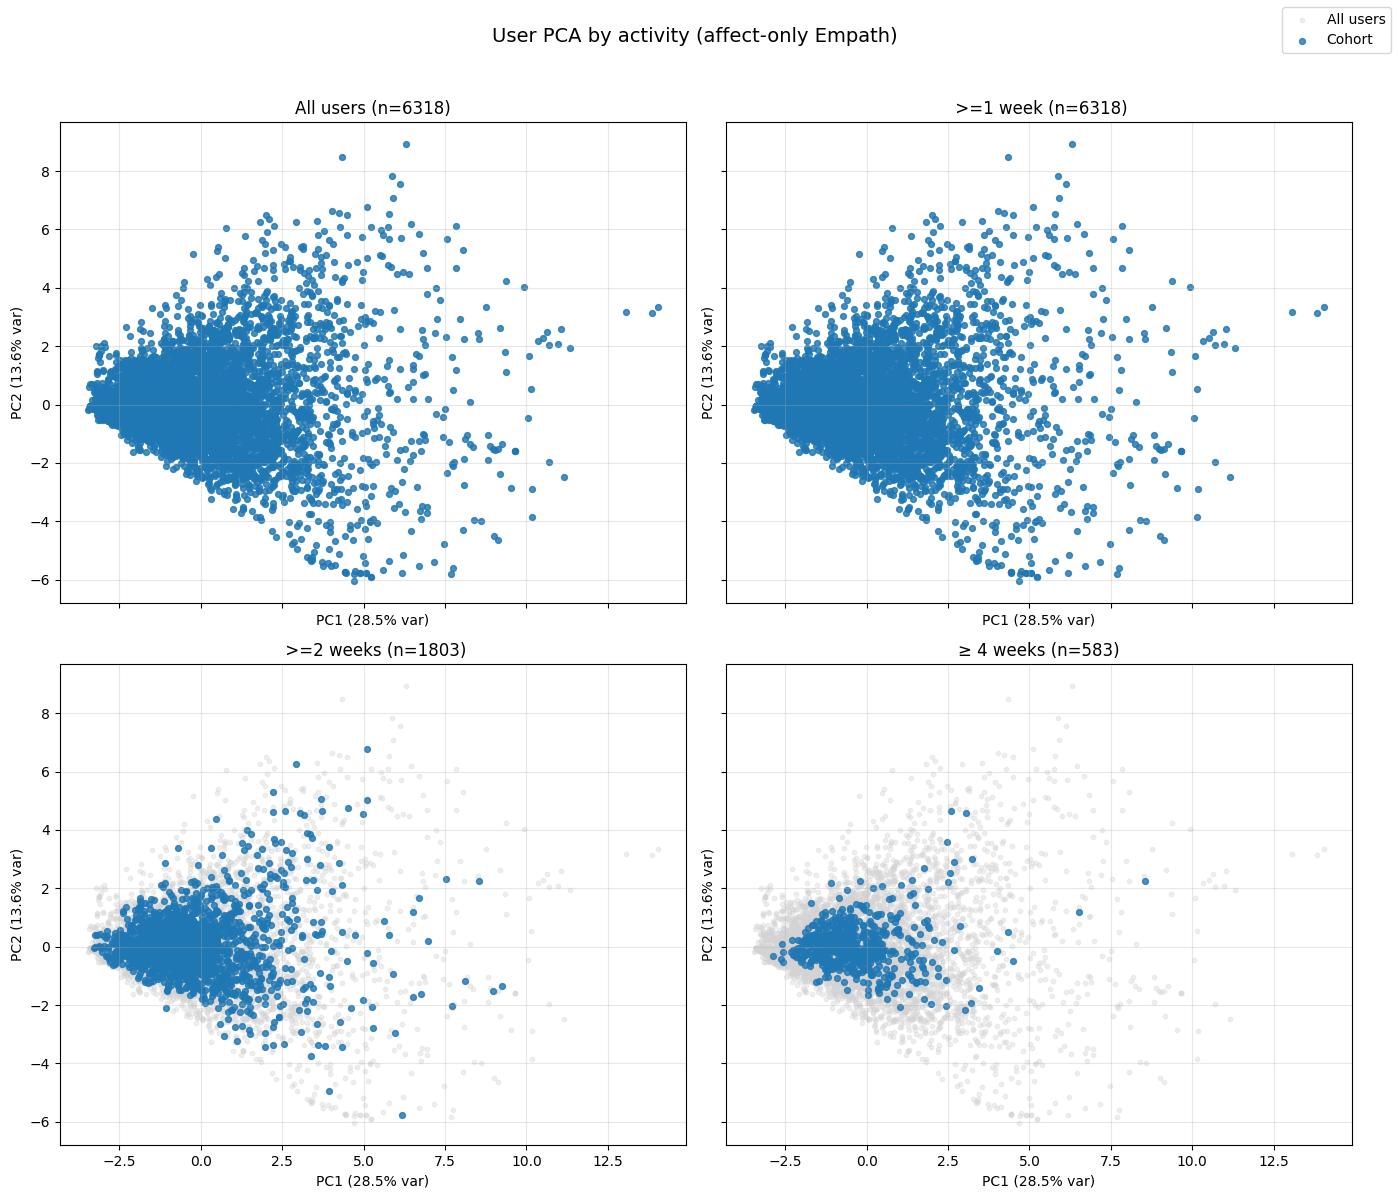

In [ ]:
def plot_user_pca_by_weeks(empath_weekly, vad_cols, winsor_q=0.99, figsize=(14, 12)):
    """
    PCA of user affect profiles, with panels for users with >=1, >=2, >=4 weeks of activity.
    """
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from sklearn.preprocessing import RobustScaler
    from sklearn.decomposition import PCA

    # Build per-user profiles
    user_profiles = (
        empath_weekly
        .groupby('user_id')[vad_cols]
        .mean()
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0.0)
    )

    # Weeks per user to define cohorts
    weeks_per_user = empath_weekly.groupby('user_id')['week'].nunique()

    # Winsorize per-feature to reduce extreme leverage
    def winsorize_df(df, q):
        hi = df.quantile(q); lo = df.quantile(1 - q)
        return df.clip(lower=lo, upper=hi, axis=1)
    user_profiles_w = winsorize_df(user_profiles, winsor_q)

    # Fit consistent axes
    X_all = RobustScaler().fit_transform(user_profiles_w)
    pca = PCA(n_components=2, random_state=42)
    Z_all = pca.fit_transform(X_all)

    # Masks
    idx_all = user_profiles_w.index
    m1 = weeks_per_user.reindex(idx_all).fillna(0).astype(int) >= 1
    m2 = weeks_per_user.reindex(idx_all).fillna(0).astype(int) >= 2
    m4p = weeks_per_user.reindex(idx_all).fillna(0).astype(int) >= 4

    panels = [
        ("All users", np.ones(len(idx_all), dtype=bool)),
        (" >=1 week", m1.values),
        (" >=2 weeks", m2.values),
        ("≥ 4 weeks", m4p.values),
    ]

    # Plot
    fig, axes = plt.subplots(2, 2, figsize=figsize, sharex=True, sharey=True)
    axes = axes.ravel()
    for ax, (title, mask) in zip(axes, panels):
        # all users
        ax.scatter(Z_all[:, 0], Z_all[:, 1], c='lightgray', s=10, alpha=0.35, label='All users')
        # cohort
        ax.scatter(Z_all[mask, 0], Z_all[mask, 1], c='#1f77b4', s=18, alpha=0.8, label=title)
        n = int(mask.sum())
        ax.set_title(f"{title} (n={n})")
        ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} var)")
        ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} var)")
        ax.grid(True, alpha=0.3)
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles[:2], ["All users","Cohort"], loc='upper right')
    fig.suptitle("User PCA by activity (affect-only Empath)", y=0.98, fontsize=14)
    plt.tight_layout(rect=[0, 0, 0.98, 0.96])
    plt.show()

    return {
        "pca": pca,
        "Z_all": Z_all,
        "index": idx_all,
        "weeks_per_user": weeks_per_user
    }
_ = plot_user_pca_by_weeks(empath_weekly, vad_cols, winsor_q=0.99)

Text(0.5, 1.0, 'Cluster centroids (affect)')

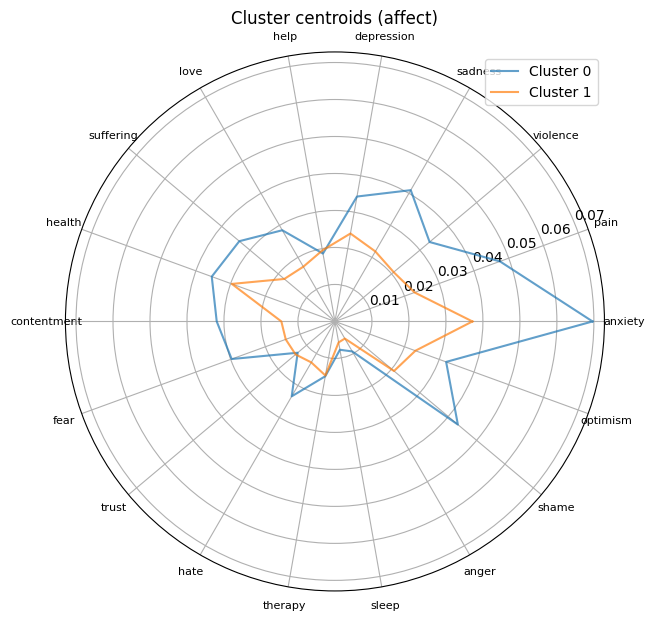

In [71]:
gm = group_means.copy(); labels = [c[7:] for c in gm.columns]
angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False); angles = np.r_[angles, angles[0]]
plt.figure(figsize=(7,7)); 
for i,(idx,row) in enumerate(gm.iterrows()):
    vals = np.r_[row.values, row.values[0]]
    ax = plt.subplot(1,1,1, projection='polar'); ax.plot(angles, vals, alpha=0.7, label=f'Cluster {idx}')
ax.set_xticks(angles[:-1]); ax.set_xticklabels(labels, fontsize=8); plt.legend(loc='upper right'); plt.title('Cluster centroids (affect)')

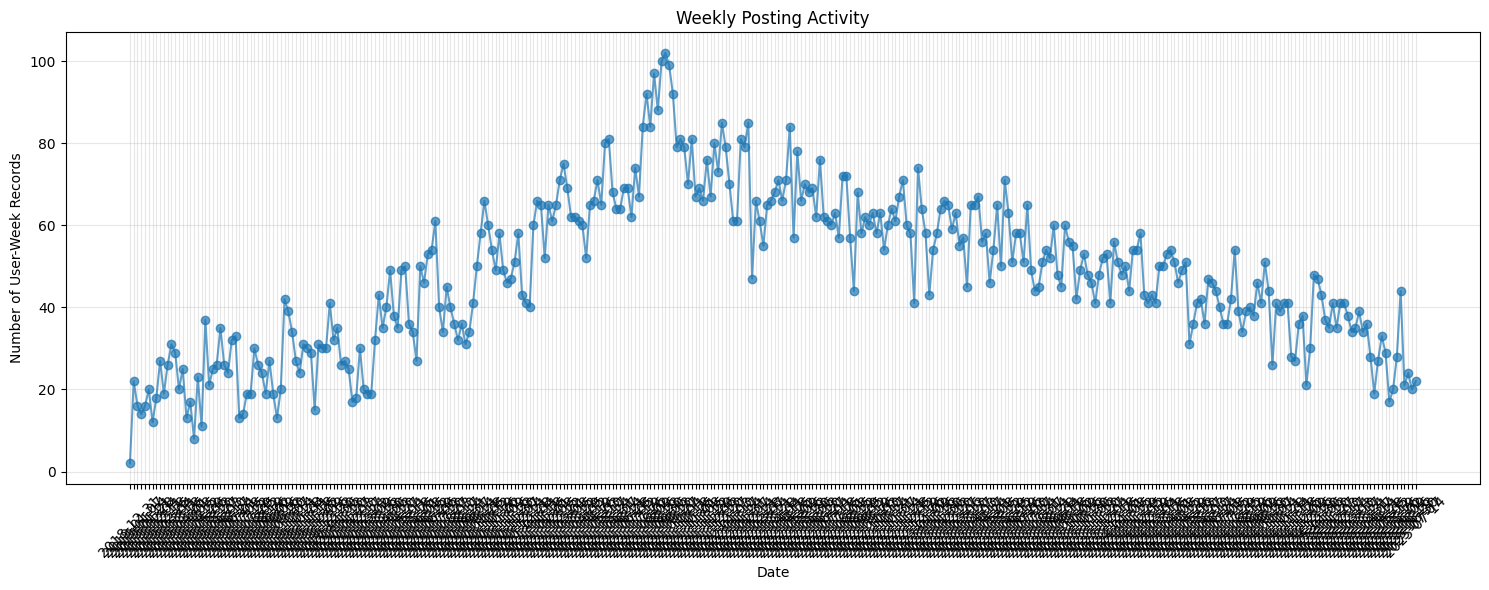

In [72]:
# Weekly posting activity
weekly_activity = empath_weekly.groupby('week').size()

plt.figure(figsize=(15, 6))
plt.plot(weekly_activity.index, weekly_activity.values, marker='o', alpha=0.7)
plt.title('Weekly Posting Activity')
plt.xlabel('Date')
plt.ylabel('Number of User-Week Records')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### 2.2.2 Observe frequent user's emotion over time

In [ ]:
# Find the most frequent users 
user_post_counts = df_vad.groupby('user_id').size().sort_values(ascending=False)
print("Top 10 most frequent users:")
print(user_post_counts.head(10))

Top 10 most frequent users:
user_id
1045    2608
1019    2026
1006    1419
1037    1255
1048    1161
1038    1051
1050     895
1116     813
1115     591
1137     445
dtype: int64


In [ ]:
# Select a frequent user
frequent_user_id = user_post_counts.index[0]  # Most frequent user
print(f"\nSelected user: {frequent_user_id} with {user_post_counts.iloc[0]} threads")


Selected user: 1045 with 2608 threads


In [75]:
# Extract this user's data over time
user_data = df_vad[df_vad['user_id'] == frequent_user_id].copy()
user_data['timestamp'] = pd.to_datetime(user_data['timestamp'])
user_data = user_data.sort_values('timestamp')

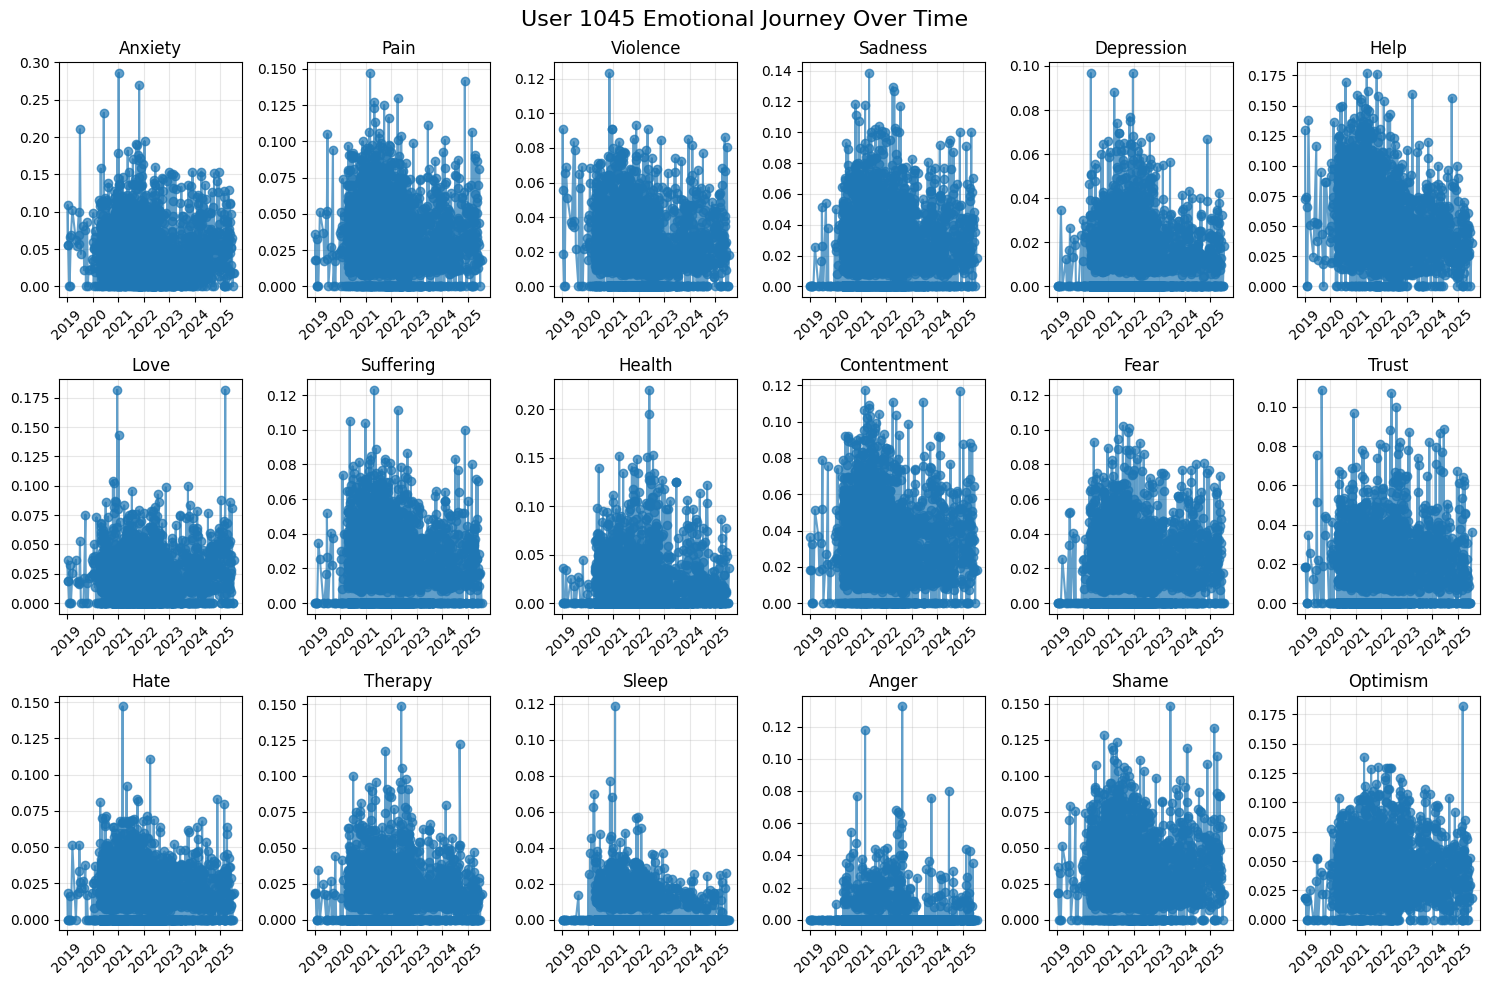

In [76]:
available_emotions = vad_cols 

plt.figure(figsize=(15, 10))

# Plot each emotion category
for i, emotion in enumerate(available_emotions):
    plt.subplot(3, 6, i+1)  # 18 emotions: 3 rows x 6 columns
    plt.plot(user_data['timestamp'], user_data[emotion], marker='o', alpha=0.7)
    plt.title(f"{emotion.replace('empath_', '').title()}")
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)

plt.suptitle(f'User {frequent_user_id} Emotional Journey Over Time', fontsize=16)
plt.tight_layout()
plt.show()

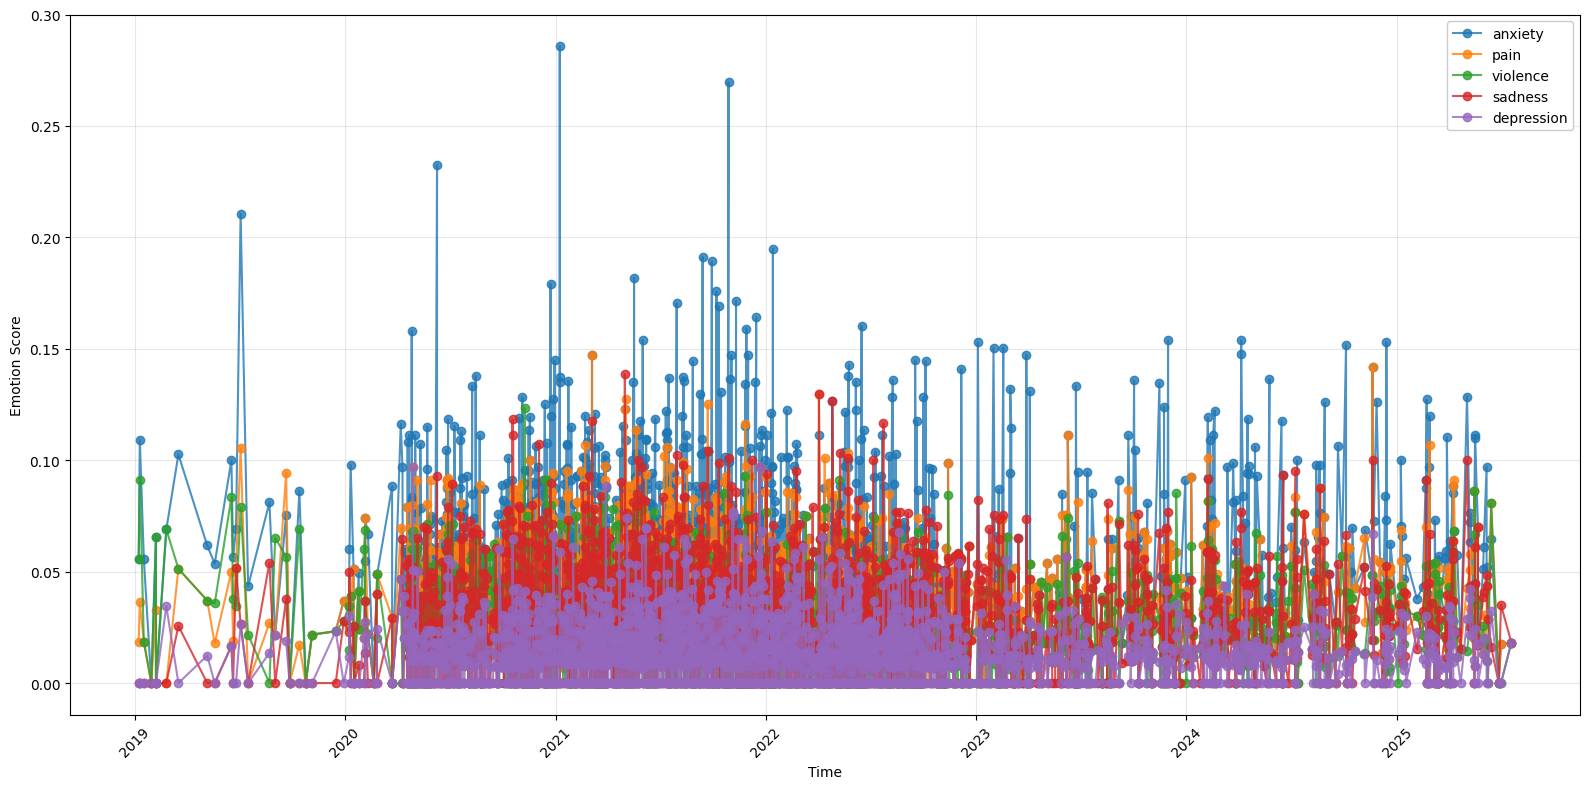

In [77]:
plt.figure(figsize=(16, 8))
for emotion in available_emotions[:5]:  # Plot top 5 emotions
    plt.plot(user_data['timestamp'], user_data[emotion], 
             label=emotion.replace('empath_', ''), marker='o', alpha=0.8)


plt.xlabel('Time')
plt.ylabel('Emotion Score')
plt.legend(loc='upper right', framealpha=1)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

We can see that Empath features simulates LIWC output and provides psychological signals extracted from the post. It numerically summarizes the content in terms of emotion, behavior, and social context.